<a href="https://colab.research.google.com/github/Sertyron/AnalisisDeReviewEnVideojuegos/blob/main/DataIII_AnalisisFinalDeVideojuegos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descripción del problema de negocio.**

##**Resumen**

La industria de los videojuegos presenta un crecimiento sostenido y acelerado año tras año, lo que la posiciona como un sector de gran interés tanto a nivel económico como cultural. En la actualidad, se trata de una de las formas de entretenimiento más valoradas por los usuarios a nivel global.

Este proyecto propone analizar la percepción de los videojuegos a lo largo del tiempo utilizando como referencia una de las plataformas de distribución digital más importantes de la industria: Steam.

Los datasets seleccionado reúne información de una muestra de videojuegos de la plataforma, elegidos tanto por su jugabilidad como por pertenecer a algunos de los géneros más populares entre los jugadores. Estos títulos fueron seleccionados para permitir un análisis más profundo, incorporando no solo datos generales de los juegos sino también comentarios y valoraciones de los usuarios, lo que permite explorar la percepción del público desde una perspectiva más cercana al comportamiento real del consumidor.

##**Objetivo del análisis**

El proyecto analizará un conjunto de videojuegos del catálogo de Steam con el propósito de comprender qué opinan los usuarios sobre estos juegos y qué aspectos valoran con mayor frecuencia.

El análisis busca identificar qué videojuegos generan mayor impacto en los jugadores, considerando variables como el género, el tipo de juego y otras características relevantes del producto.

A su vez, se plantea un enfoque particular: aunque cada videojuego es un producto individual, también forma parte de un ecosistema más amplio dentro de la industria. Desde la perspectiva del usuario, la elección de un juego no ocurre de manera aislada, sino dentro de un conjunto amplio de opciones disponibles en el mercado. Por esta razón, el estudio se abordará tanto desde una perspectiva cuantitativa (datos, métricas y tendencias) como cualitativa (opiniones y percepciones de los usuarios).

Asimismo, se busca comprender cómo se construye la valoración subjetiva del usuario promedio a lo largo del tiempo y si existen patrones comunes entre los títulos mejor valorados.

Finalmente, el objetivo es desarrollar un modelo exploratorio de análisis del mercado, que permita identificar tendencias relevantes para futuros proyectos, como los géneros más valorados por los usuarios y los factores que influyen en el interés del público.

# **Recursos a Importar**

In [ ]:
#Importar Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importar Todos los Data frame

# Este es el Data frame Original
!gdown 1hQgW2gPTvnJp5R7fp0yqfwKWSwOVg6CQ
!gdown 1friNh64ngAfQNeQ_laafriJnmI7xEPQh

Downloading...
From: https://drive.google.com/uc?id=1hQgW2gPTvnJp5R7fp0yqfwKWSwOVg6CQ
To: /content/Data_Muestra2.xlsx
100% 12.9k/12.9k [00:00<00:00, 41.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1friNh64ngAfQNeQ_laafriJnmI7xEPQh
To: /content/Data_Reseña2.xlsx
100% 1.73M/1.73M [00:00<00:00, 65.2MB/s]


In [ ]:
#Asociar la ruta a una variable
df_mustraTotal = pd.read_excel('/content/Data_Muestra2.xlsx')
df_reviews_total = pd.read_excel('/content/Data_Reseña2.xlsx')

In [ ]:
#Este es el Data Frame despues de una limpieza mas especifica que se vera acontinuacion pero
#en resumen es la iteracion para empezar a armar modelos y y graficos
!gdown 1gQAt0Sdopzcqv2VuMDJWGuZ5sO8K699o

Downloading...
From: https://drive.google.com/uc?id=1gQAt0Sdopzcqv2VuMDJWGuZ5sO8K699o
To: /content/Data_Frame_V2.xlsx
100% 7.96M/7.96M [00:00<00:00, 23.1MB/s]


In [ ]:
dfData2 = pd.read_excel('/content/Data_Frame_V2.xlsx')

# **Como queda sin hacer cambios el NLP**



In [ ]:
df_reviews_total.head()

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,Gambling simulator with cheaters and guns! Bes...,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,Click heads = satisfying . \r\nClick anything ...,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,gold gold gold!\ni love gambling but if i open...,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,this game contains way too many stupid russian...,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN


Aqui se ve la primera prueba de NLP la cual se hizo como modo de investigacion en otro proyecto donde no se habia estudiado a fondo el tipo de modelo en especifico.

Accuracy: 0.8809766022380467

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.65      0.77       297
           1       0.87      0.98      0.92       686

    accuracy                           0.88       983
   macro avg       0.90      0.82      0.84       983
weighted avg       0.89      0.88      0.87       983



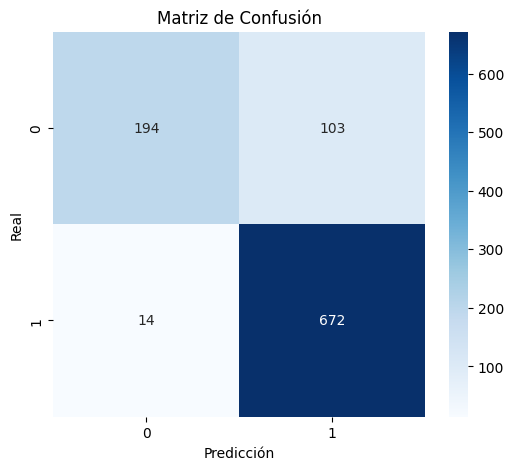

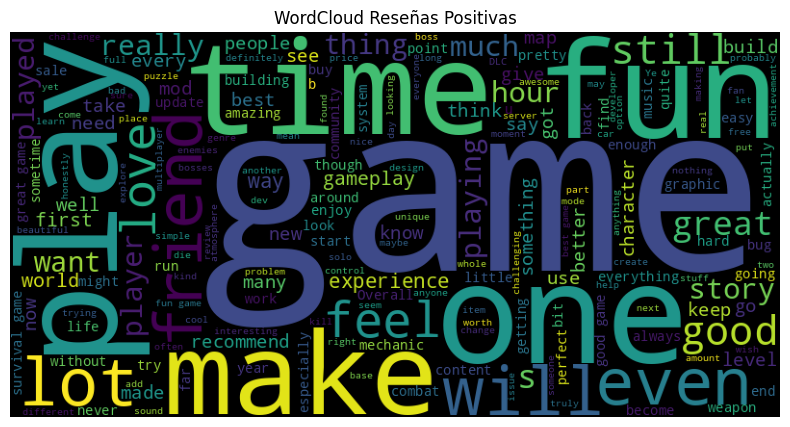

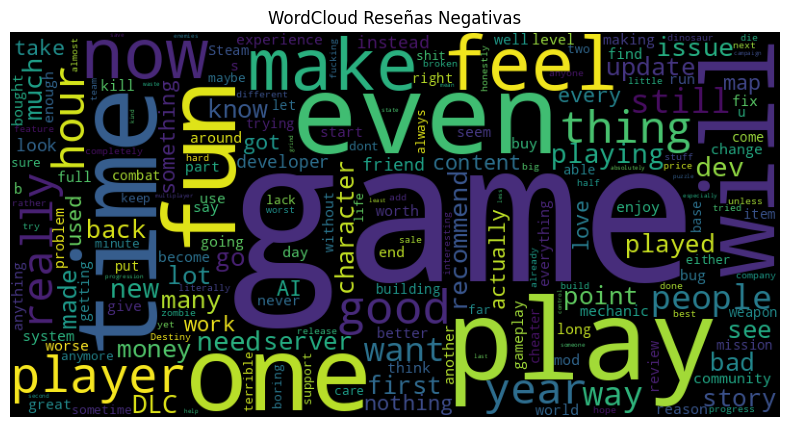

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Filtrado recomendado ---
df = df_reviews_total.copy()

df = df[df["review"].str.len() > 20]
df = df[df["steam_purchase"] == True]

# Convertir 'weighted_vote_score' a numericos
df["weighted_vote_score"] = pd.to_numeric(df["weighted_vote_score"], errors='coerce')
# Eliminar Nan
df = df.dropna(subset=["weighted_vote_score"])
df = df[df["weighted_vote_score"] > 0]

X = df["review"]
y = df["voted_up"].astype(int)

# --- 2. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. TF-IDF ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- 4. Modelo ---
model = LogisticRegression(max_iter=500)
model.fit(X_train_tfidf, y_train)

# --- 5. Predicciones ---
y_pred = model.predict(X_test_tfidf)

# --- 6. Métricas ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# --- 7. Matriz de confusión ---
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# --- 8. WordCloud Positivo ---
positive_reviews = " ".join(df[df["voted_up"]==1]["review"])
wordcloud_pos = WordCloud(width=800, height=400).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud Reseñas Positivas")
plt.show()

# --- 9. WordCloud Negativo ---
negative_reviews = " ".join(df[df["voted_up"]==0]["review"])
wordcloud_neg = WordCloud(width=800, height=400).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud Reseñas Negativas")
plt.show()

Lo que noste es que hay muchas palabras inecesarias cosas que despues se intenta quitar pero que en algunos casos solo vuleven a aparecen por lo que primero obvio los elementos inecesarios como investigador y busco Insigth

# Entendimiento de Datos claves

Voy a buscar los elementos mas iconicos del dataset actual para asi ver que tiene valor de busqueda

In [ ]:
df_reviews_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   recommendationid             4955 non-null   int64  
 1   author                       4955 non-null   object 
 2   language                     4955 non-null   object 
 3   review                       4955 non-null   object 
 4   timestamp_created            4955 non-null   int64  
 5   timestamp_updated            4955 non-null   int64  
 6   voted_up                     4955 non-null   bool   
 7   votes_up                     4955 non-null   int64  
 8   votes_funny                  4955 non-null   int64  
 9   weighted_vote_score          4955 non-null   float64
 10  comment_count                4955 non-null   int64  
 11  steam_purchase               4955 non-null   bool   
 12  received_for_free            4955 non-null   bool   
 13  written_during_ear

In [ ]:
df_reviews_total.head()

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,Gambling simulator with cheaters and guns! Bes...,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,Click heads = satisfying . \r\nClick anything ...,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,gold gold gold!\ni love gambling but if i open...,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,this game contains way too many stupid russian...,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN


In [ ]:
df_reviews_total['voted_up'].value_counts()

,count
voted_up,
True,3440
False,1515


Se ve un desvalance entre postivas y negativas pero es util como muestra de desarrollo

# **Datos relevantes para Insight, observaciones y resultados obtenidos**

Aquí se utilizará un dataset comunal previamente normalizado y limpio, que servirá como base para el análisis. Este dataset contiene una muestra de videojuegos seleccionados para generar observaciones útiles dentro de la investigación. A partir de esta base también será posible obtener información relevante sobre las reseñas de los usuarios y utilizarlas en futuros análisis del proyecto.

In [ ]:
df.head()

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,Gambling simulator with cheaters and guns! Bes...,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,Click heads = satisfying . \r\nClick anything ...,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,gold gold gold!\ni love gambling but if i open...,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,this game contains way too many stupid russian...,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN


# Graficos

In [ ]:
#ponermos el DataFrame2 a Funcionar
df = dfData2.copy()

In [ ]:
import plotly.express as px

# Contar cantidad de juegos por developer
dev_games = (
    df.groupby("Developer")["Title"]
    .count()
    .reset_index()
    .rename(columns={"Title": "Cantidad_Juegos"})
)

# Tomamos los 10 developers con más juegos
top_dev_games = dev_games.sort_values("Cantidad_Juegos", ascending=False).head(10)

# Gráfico de barras
fig = px.bar(
    top_dev_games,
    x="Developer",
    y="Cantidad_Juegos",
    text="Cantidad_Juegos",
    title="Top 10 desarrolladores con más juegos en el dataset",
    labels={
        "Developer": "Desarrollador",
        "Cantidad_Juegos": "Cantidad de juegos"
    }
)

fig.update_traces(textposition="outside")
fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [ ]:
import plotly.express as px

# Agrupamos por developer
dev_players = (
    df.groupby("Developer")
    .agg(
        Juegos=("Title", "count"),
        Jugadores_Totales=("Jugadores_Actuales", "sum")
    )
    .reset_index()
)

# Top 10 por jugadores
top_dev_players = dev_players.sort_values(
    "Jugadores_Totales",
    ascending=False
).head(10)

# Crear texto con juegos + jugadores
top_dev_players["Info"] = (
    "Juegos: " + top_dev_players["Juegos"].astype(str)
)

# Gráfico
fig = px.bar(
    top_dev_players,
    x="Developer",
    y="Jugadores_Totales",
    text="Info",
    title="Desarrolladores con más jugadores totales en Steam",
    labels={
        "Developer": "Desarrollador",
        "Jugadores_Totales": "Jugadores actuales totales"
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [ ]:
import plotly.express as px

# Contar categorías de reseñas
reviews = (
    df["Recent Reviews Summary"]
    .value_counts()
    .reset_index()
)

reviews.columns = ["Tipo_Reseña", "Cantidad"]

# Gráfico de torta
fig = px.pie(
    reviews,
    names="Tipo_Reseña",
    values="Cantidad",
    title="Distribución de popularidad según reseñas recientes"
)

fig.show()

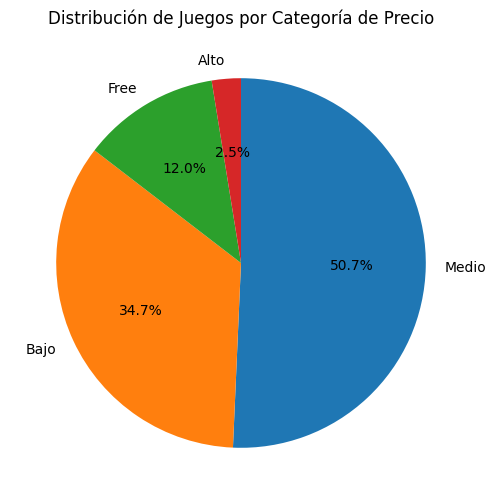

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear categorías
def categorizar_precio(x):
    try:
        x = float(x)
    except:
        return "Free"   # por si hay nulos o valores raros
    if x == 0:
        return "Free"
    elif 1 <= x <= 5.99:
        return "Bajo"
    elif 6 <= x <= 24.99:
        return "Medio"
    elif x >= 25:
        return "Alto"
    else:
        return "Free"

df["Categoria_Precio"] = df["Discounted Price"].apply(categorizar_precio)

# Contar valores por categoría
conteo = df["Categoria_Precio"].value_counts()

# Gráfico de torta
plt.figure(figsize=(6,6))
plt.pie(conteo, labels=conteo.index, autopct="%1.1f%%", startangle=90, counterclock=False)
plt.title("Distribución de Juegos por Categoría de Precio")
plt.show()


In [ ]:
##Vamos a hacer un grafico para ver el top 10 de juegos que se estan jugando en Steam

import plotly.express as px

# Ordenamos por jugadores y tomamos los 10 primeros
top10 = df.sort_values("Jugadores_Actuales", ascending=False).head(10)

# Creamos gráfico de barras interactivo
fig = px.bar(
    top10,
    x="Title",
    y="Jugadores_Actuales",
    text="Jugadores_Actuales",
    title="Top 10 juegos más jugados ahora en Steam",
    labels={"Title": "Juego", "Jugadores_Actuales": "Jugadores Actuales"},
)

# Personalización: rotar nombres y poner texto encima
fig.update_traces(texttemplate='%{text:,}', textposition="outside")
fig.update_layout(xaxis_tickangle=-45)

fig.show()


In [ ]:
import plotly.express as px

# Ordenamos por jugadores actuales y tomamos el top 10
top10 = df.sort_values("Jugadores_Actuales", ascending=False).head(10)

# Seleccionamos columnas necesarias
df_compare = top10[["Title", "Jugadores_Actuales", "Jugadores_Dia:12_10_2025"]]

# Convertimos a formato largo para poder apilar barras
df_melt = df_compare.melt(
    id_vars="Title",
    value_vars=["Jugadores_Actuales", "Jugadores_Dia:12_10_2025"],
    var_name="Tipo de Jugadores",
    value_name="Cantidad"
)

# Creamos gráfico de barras apiladas
fig = px.bar(
    df_melt,
    x="Title",
    y="Cantidad",
    color="Tipo de Jugadores",
    title="Comparación de jugadores actuales vs jugadores del día anterior (Top 10 Steam)",
    labels={
        "Title": "Juego",
        "Cantidad": "Cantidad de jugadores",
        "Tipo de Jugadores": "Métrica"
    }
)

# Ajustes visuales
fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [ ]:
# Acá veo la columna "géneros" y armo la parte de los gráficos para identificar cuál es el género más popular.
from collections import Counter

# Aplanar lista de listas de géneros
todos_generos = [g for lista in df["Géneros"] for g in lista]
conteo_generos = Counter(todos_generos)
df_generos = pd.DataFrame(conteo_generos.items(), columns=["Género", "Cantidad"])
df_generos = df_generos.sort_values("Cantidad", ascending=False)

In [ ]:
import ast
from collections import Counter
import pandas as pd
import plotly.express as px
from ipywidgets import widgets, Output
from IPython.display import display, clear_output

# --- Función robusta que transforma una entrada 'Géneros' en una lista de strings legibles
def normalize_genre_entry(entry):
    """
    Devuelve una lista de géneros a partir de entry.
    Soporta:
     - listas/tuplas reales: ['Action','Adventure']
     - strings que contienen la representación de una lista: "['Action']"
     - strings con coma: "Action, Adventure"
     - strings simples: "Action"
    """
    if pd.isna(entry):
        return ["Desconocido"]
    # lista/tuple/set real
    if isinstance(entry, (list, tuple, set)):
        return [str(x).strip() for x in entry if x is not None and str(x).strip() != ""]
    # string: intentar parsear literal_eval si parece lista/tupla
    if isinstance(entry, str):
        s = entry.strip()
        # intenta literal_eval si tiene corchetes/paréntesis
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, set)):
                    return [str(x).strip() for x in parsed if x is not None and str(x).strip() != ""]
            except Exception:
                # si falla, caemos al fallback
                pass
        # si contiene comas (y no es una URL), partir por comas
        if "," in s and "http" not in s:
            parts = [p.strip().strip('\'"') for p in s.split(",") if p.strip()]
            if parts:
                return parts
        # fallback: string simple (quitar comillas sobrantes)
        return [s.strip().strip('\'"')]
    # otros tipos (int, float, etc.)
    return [str(entry)]

# --- Construir lista plana de géneros sin modificar df_procesado ---
todos_generos = []
for val in df["Géneros"]:
    normalized = normalize_genre_entry(val)
    todos_generos.extend(normalized)

# --- Contar y crear df_generos ---
conteo_generos = Counter(todos_generos)
df_generos = pd.DataFrame(conteo_generos.items(), columns=["Género", "Cantidad"])
df_generos = df_generos.sort_values("Cantidad", ascending=False).reset_index(drop=True)

# Opcional: diagnostico rápido de entradas problemáticas originales (para que veas por qué pasaba)
# Muestra los tipos más comunes en df_procesado["Géneros"]
from collections import defaultdict
tipo_examples = defaultdict(list)
for v in df["Géneros"].head(200):  # chequeo sólo primeras 200 para no saturar
    tipo_examples[type(v).__name__].append(v)
print("Tipos detectados (ejemplos):")
for k, ex in tipo_examples.items():
    print(f"  {k}: ejemplo -> {ex[:2]}")  # muestro hasta 2 ejemplos por tipo

# --- Mostrar df_generos para verificar ---
display(df_generos.head(20))

# --- Plotly: Top 3 y selector interactivo (options = géneros legibles) ---
top3 = df_generos.head(3).copy()

fig = px.bar(
    top3,
    x="Género",
    y="Cantidad",
    title="Top 3 géneros más comunes",
    text="Cantidad",
    color="Género"
)
fig.update_traces(texttemplate="%{y:,}", textposition="outside", marker_line_width=0)
fig.update_layout(xaxis_title="Género", yaxis_title="Cantidad", showlegend=False, margin=dict(l=80, r=40, t=80, b=80))
fig.show()

# --- Selector interactivo (hasta 5 géneros) ---
opciones = df_generos["Género"].tolist()

selector = widgets.SelectMultiple(
    options=opciones,
    value=opciones[:3] if len(opciones) >= 3 else opciones,
    description='Géneros:',
    rows=6
)

out = Output()

def build_grouped_for_selection(sel_clean):
    # sel_clean aquí ya son géneros limpios (tal cual aparecen en df_generos)
    if not sel_clean:
        sel_clean = opciones[:3]
    df_sel = df_generos[df_generos["Género"].isin(sel_clean)].copy()
    return df_sel.sort_values("Cantidad", ascending=False)

def actualizar(change=None):
    seleccion = list(selector.value)[:5]
    if len(seleccion) == 0:
        seleccion = opciones[:3]
    df_sel = build_grouped_for_selection(seleccion)
    fig = px.bar(df_sel, x="Género", y="Cantidad", text="Cantidad", color="Género",
                 title=f"Comparativa de géneros seleccionados ({len(seleccion)})")
    fig.update_traces(texttemplate="%{y:,}", textposition="outside", marker_line_width=0)
    fig.update_layout(xaxis_title="Género", yaxis_title="Cantidad", showlegend=False, margin=dict(l=80, r=40, t=70, b=80))
    with out:
        clear_output(wait=True)
        fig.show()

selector.observe(actualizar, names='value')
display(selector)
display(out)
actualizar()


Tipos detectados (ejemplos):
  str: ejemplo -> ["['Adventure', 'RPG', 'Strategy']", "['Action', 'Free To Play']"]


,Género,Cantidad
0,Indie,934
1,Action,682
2,Adventure,630
3,Casual,457
4,Strategy,338
5,Simulation,337
6,RPG,328
7,Early Access,88
8,Free To Play,87
9,Sports,74


SelectMultiple(description='Géneros:', index=(0, 1, 2), options=('Indie', 'Action', 'Adventure', 'Casual', 'St…

Output()

In [ ]:
#normalizar datos para que quede todo con el mismo nombre
df_generos['Género'] = df_generos['Género'].replace({
    'Accion': 'Action',
    'Acción': 'Action',
    'Aksi': 'Action',
    'Ação': 'Action',
    'Aventura': 'Adventure',
    'Petualangan':'Adventure',
    'Estratégia': 'Strategy',
    'Simulationen': 'Simulation',
    'Simulación': 'Simulation',
    'Simulasi':'Simulation'

})


In [ ]:
df_generos = df_generos.groupby('Género', as_index=False)['Cantidad'].sum()


###Informe de Resultados

Se realizaron diversos gráficos para identificar las principales tendencias del mercado de videojuegos en Steam. En primer lugar, se observa una marcada predominancia de títulos free-to-play, lo cual resulta lógico considerando que muchos de estos proyectos son de pequeño o mediano alcance, orientados a modelos de monetización diferida o creados como parte de prácticas profesionales y portfolios. Este enfoque busca maximizar el alcance y la cantidad de jugadores, priorizando la difusión sobre la ganancia inmediata.

Tambien parece que comparar los juegos de Valve contra otro es claramante desregular cosa que tiene sentido al ser Steam la empresa distribuidora creada por valve lo que hace que sus numero no esten desvirtuados ademas de que sus servicio sea posiblemente mejor para sus propios juegos.

tambien podemos asumir por el grafico recepcion

Asimismo, se aprecia una diferencia significativa entre los juegos más jugados y el resto del catálogo. Incluso, a partir del segundo puesto, las métricas disminuyen de forma abrupta. Esto puede explicarse porque el conjunto de datos original contiene registros hasta 2023, reflejando la consistencia y permanencia de los títulos más populares antes que el efecto de lanzamientos recientes o fenómenos de “FOMO”.

Sin embargo, será necesario observar su evolución con el paso del tiempo para determinar si mantiene esa tendencia. Casos similares ocurrieron con varios juegos que figuran en el top 10 del conjunto analizado: títulos que presentaron picos de jugadores en su lanzamiento, pero cuya base activa se estabilizó posteriormente.

En síntesis, los datos sugieren que los títulos con alta expectativa o fuerte interés del público suelen alcanzar un rendimiento inicial destacado, aunque su permanencia en el tiempo depende de la capacidad de sostener ese interés más allá del lanzamiento.

# Proceso correcto del Procesamiento del Lenguaje Natural (PLN) O NLtk

In [ ]:
df_NLP = df_reviews_total.copy()

In [ ]:
df_NLP

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,Gambling simulator with cheaters and guns! Bes...,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,Click heads = satisfying . \r\nClick anything ...,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,gold gold gold!\ni love gambling but if i open...,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,this game contains way too many stupid russian...,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,32080918,"{'steamid': '76561198188515021', 'num_games_ow...",english,Like Centipede but bad.\nNot bad meaning bad\n...,1496220459,1496220459,True,2,0,0.454197,0,True,False,False,False,447950,NaN,NaN
4951,47192162,"{'steamid': '76561198169811581', 'num_games_ow...",english,It's sorta like Space Invaders but a bit more ...,1543514123,1543514123,True,2,0,0.460277,0,True,False,False,False,447950,NaN,NaN
4952,29413529,"{'steamid': '76561198054387451', 'num_games_ow...",english,Short-lived...like a CATERPILLAR UNDER MY SHOE...,1485058955,1485058955,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN
4953,93086769,"{'steamid': '76561199042140510', 'num_games_ow...",english,i am nerd....came hard for some reason,1622694992,1622694992,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN


In [ ]:
# Visualizamos algunas de las reviews.

# La número 49
print(df_NLP.loc[50, 'review'])
print("\n" + "-"*80 + "\n")  # línea separadora


# La número 300
print(df_NLP.loc[301, 'review'])
print("\n" + "-"*80 + "\n")  # línea separadora


# La número 4954 (última fila)
print(df_NLP.loc[4954, 'review'])
print("\n" + "-"*80 + "\n")  # línea separadora

Nice game

--------------------------------------------------------------------------------

Meh, doesn't hold up to current times. I set up a personal server to play it because I'm not a PvP fan, was pretty easy to do but it wasn't all it's cracked up to be.

--------------------------------------------------------------------------------

I am 32 years old.

My ex-wife and I have a daughter together, and we adopted our son together. Both are now 4 years old.

When we were going through our separation, I felt lost and unhappy. I was self-destructive. One day, I was so angry with everything spiraling out of control that I punched a concrete wall in a moment of overwhelming emotion. This resulted in breaking my fifth metacarpal in my right hand—the hand I worked with, played games with, and used to carry my children to bed—the hand I desperately needed to ensure I could continue providing.

Upon learning the severity of the self-inflicted damage, I became almost suicidal. Keep in mind t

# Normalizar Datos NLP

In [ ]:
# Guardamos todas las columnas excepto "review"
cols = [col for col in df_NLP.columns if col != "review"]

# Reordenamos poniendo "review" al final
df_NLP = df_NLP[cols + ["review"]]

In [ ]:
#  ¿Qué hace .lower()? Convierte todo el texto a minúsculas.

# No necesitás importar ninguna librería para usar .lower(), ya que es un método incorporado en los objetos de tipo str en Python.
# Esto significa que cualquier texto (cadena de caracteres) puede convertirse a minúsculas directamente con .lower().
#  Es útil para normalizar texto antes de analizarlo o procesarlo.
df_NLP['review_lower'] = df_NLP['review'].apply(lambda text: text.lower())


/tmp/ipykernel_19515/1696575434.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_NLP

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response,review,review_lower
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN,Gambling simulator with cheaters and guns! Bes...,gambling simulator with cheaters and guns! bes...
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN,Click heads = satisfying . \r\nClick anything ...,click heads = satisfying . \r\nclick anything ...
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,quotation forthcoming.\n\nedit:\n\ncounter-str...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,32080918,"{'steamid': '76561198188515021', 'num_games_ow...",english,1496220459,1496220459,True,2,0,0.454197,0,True,False,False,False,447950,NaN,NaN,Like Centipede but bad.\nNot bad meaning bad\n...,like centipede but bad.\nnot bad meaning bad\n...
4951,47192162,"{'steamid': '76561198169811581', 'num_games_ow...",english,1543514123,1543514123,True,2,0,0.460277,0,True,False,False,False,447950,NaN,NaN,It's sorta like Space Invaders but a bit more ...,it's sorta like space invaders but a bit more ...
4952,29413529,"{'steamid': '76561198054387451', 'num_games_ow...",english,1485058955,1485058955,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN,Short-lived...like a CATERPILLAR UNDER MY SHOE...,short-lived...like a caterpillar under my shoe...
4953,93086769,"{'steamid': '76561199042140510', 'num_games_ow...",english,1622694992,1622694992,True,0,0,0.500000,0,True,False,False,False,447950,NaN,NaN,i am nerd....came hard for some reason,i am nerd....came hard for some reason


In [ ]:
import re

# Definir una función que remueva los signos de puntuación usando re
def remove_punctuation(text):
    # Expresión regular para reemplazar cualquier signo de puntuación o símbolo no alfanumérico
     return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Aplicar la función a la columna 'review_lower'
df_NLP['review_puntuacion'] = df_NLP['review_lower'].apply(remove_punctuation)

/tmp/ipykernel_19515/444297520.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_NLP.head(5)

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response,review,review_lower,review_puntuacion
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,True,False,False,False,730,NaN,NaN,Gambling simulator with cheaters and guns! Bes...,gambling simulator with cheaters and guns! bes...,gambling simulator with cheaters and guns best...
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,True,False,False,False,730,NaN,NaN,Click heads = satisfying . \r\nClick anything ...,click heads = satisfying . \r\nclick anything ...,click heads satisfying \r\nclick anything el...
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,True,False,False,False,730,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...,gold gold gold\ni love gambling but if i open ...
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,True,False,False,False,730,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...,this game contains way too many stupid russian...
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,True,False,False,False,730,NaN,NaN,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,quotation forthcoming.\n\nedit:\n\ncounter-str...,quotation forthcoming\n\nedit\n\ncounterstrike...


## Tokenizacion de palabras

In [ ]:
# Importamos las librerías necesarias
import nltk

nltk.download('punkt')  # Descargamos el paquete de tokenización de NLTK
nltk.download('punkt_tab')  # Descargamos el paquete de tokenización de NLTK
from nltk.tokenize import word_tokenize # Desde el módulo nltk.tokenize, quiero importar solo la función word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Tokenizamos los valores de la columna 'review'
df_NLP['review_tokenizado'] = df_NLP['review_puntuacion'].apply(word_tokenize)


/tmp/ipykernel_19515/302258519.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# Configuramos pandas para mostrar el contenido completo de las columnas
pd.set_option('display.max_colwidth', None)

In [ ]:
# Mostramos las primeras filas con la columna original y de la columna tokenizada
df_NLP[['review', 'review_tokenizado']].head()

,review,review_tokenizado
0,Gambling simulator with cheaters and guns! Best FPS game out there despite glaring issues.,"[gambling, simulator, with, cheaters, and, guns, best, fps, game, out, there, despite, glaring, issues]"
1,Click heads = satisfying . \r\nClick anything else = dog sh1t game,"[click, heads, satisfying, click, anything, else, dog, sh1t, game]"
2,gold gold gold!\ni love gambling but if i open up one more case and dont get a knife im jumping o0ff a bridge (hypothetically),"[gold, gold, gold, i, love, gambling, but, if, i, open, up, one, more, case, and, dont, get, a, knife, im, jumping, o0ff, a, bridge, hypothetically]"
3,this game contains way too many stupid russians but atleast its fun to play sometimes,"[this, game, contains, way, too, many, stupid, russians, but, atleast, its, fun, to, play, sometimes]"
4,"Quotation forthcoming.\n\nEDIT:\n\nCounter-Strike 2’s wall of noise and violence will feel impenetrable to newcomers but a welcome upgrade for long-term Counter-Strike fans. It’s the best competitive shooter on the market, but it’s so difficult for new players to get on board that it won’t be for everyone.","[quotation, forthcoming, edit, counterstrike, 2s, wall, of, noise, and, violence, will, feel, impenetrable, to, newcomers, but, a, welcome, upgrade, for, longterm, counterstrike, fans, its, the, best, competitive, shooter, on, the, market, but, its, so, difficult, for, new, players, to, get, on, board, that, it, wont, be, for, everyone]"


In [ ]:
# Restauramos la configuración predeterminada de pandas para el ancho de las columnas
pd.reset_option('display.max_colwidth')

## Quitar las Stopword o palabras conectoras

In [ ]:
# Previsualizamos algunas stopwords previstas en la librería.

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Obtenemos el listado de stopwords en español
stopwords_eng = stopwords.words('english')

# Mostramos las primeras 20
print(stopwords_eng[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Importamos stopwords de NLTK (Pueden importarse tanto para español como para inglés)
nltk.download('stopwords') # Descargamos el paquete de stopwords de NLTK para poder usarlas en el código
from nltk.corpus import stopwords # Importamos el módulo de stopwords desde NLTK, que contiene listas de palabras vacías

# Lista de stopwords en inglés
stop_words = set(stopwords.words('english')) # Creamos un conjunto de stopwords en inglés usando NLTK

# Función para eliminar stopwords de los tokens
# Aplicamos una función lambda a cada fila de la columna 'review_tokenizado'
df_NLP['review_tokenizado_sin_stopwords'] = df_NLP['review_tokenizado'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
    # La función lambda toma cada lista de tokens (palabras tokenizadas de la reseña),
    # y devuelve una nueva lista donde solo quedan las palabras que no están en la lista de stopwords.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_19515/1957454293.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



El uso de palabras cortadas

In [ ]:
# Importar el PorterStemmer de nltk
from nltk.stem import PorterStemmer

# Inicializar el stemmer
stemmer = PorterStemmer()

# Aplicar stemming a la columna 'review_tokenizado_sin_stopwords'
df_NLP['review_stemming'] = df_NLP['review_tokenizado_sin_stopwords'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])


/tmp/ipykernel_19515/3200408334.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Las palabras compuestas de ingles Ejem Get out

In [ ]:
#Importamos librerías

import nltk
nltk.download('wordnet')  # Base de datos léxica de WordNet para lematización en inglés

# Importar el WordNetLemmatizer de nltk
from nltk.stem import WordNetLemmatizer

# Inicializar el lematizador
lemmatizer = WordNetLemmatizer()

# Aplicar la lematización a la columna 'review_tokenizado_sin_stopwords'
df_NLP['review_lematizacion'] = df_NLP['review_tokenizado_sin_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

[nltk_data] Downloading package wordnet to /root/nltk_data...
/tmp/ipykernel_19515/3751493181.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
#Resultados finales con los textos limpios para empezar a trabajar
df_NLP.head(15)

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,appid,timestamp_dev_responded,developer_response,review,review_lower,review_puntuacion,review_tokenizado,review_tokenizado_sin_stopwords,review_stemming,review_lematizacion
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,...,730,NaN,NaN,Gambling simulator with cheaters and guns! Bes...,gambling simulator with cheaters and guns! bes...,gambling simulator with cheaters and guns best...,"[gambling, simulator, with, cheaters, and, gun...","[gambling, simulator, cheaters, guns, best, fp...","[gambl, simul, cheater, gun, best, fp, game, d...","[gambling, simulator, cheater, gun, best, fps,..."
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,...,730,NaN,NaN,Click heads = satisfying . \r\nClick anything ...,click heads = satisfying . \r\nclick anything ...,click heads satisfying \r\nclick anything el...,"[click, heads, satisfying, click, anything, el...","[click, heads, satisfying, click, anything, el...","[click, head, satisfi, click, anyth, els, dog,...","[click, head, satisfying, click, anything, els..."
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,...,730,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...,gold gold gold\ni love gambling but if i open ...,"[gold, gold, gold, i, love, gambling, but, if,...","[gold, gold, gold, love, gambling, open, one, ...","[gold, gold, gold, love, gambl, open, one, cas...","[gold, gold, gold, love, gambling, open, one, ..."
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,...,730,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...,this game contains way too many stupid russian...,"[this, game, contains, way, too, many, stupid,...","[game, contains, way, many, stupid, russians, ...","[game, contain, way, mani, stupid, russian, at...","[game, contains, way, many, stupid, russian, a..."
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,...,730,NaN,NaN,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,quotation forthcoming.\n\nedit:\n\ncounter-str...,quotation forthcoming\n\nedit\n\ncounterstrike...,"[quotation, forthcoming, edit, counterstrike, ...","[quotation, forthcoming, edit, counterstrike, ...","[quotat, forthcom, edit, counterstrik, 2s, wal...","[quotation, forthcoming, edit, counterstrike, ..."
5,212041886,"{'steamid': '76561199797065377', 'num_games_ow...",english,1764525066,1764525066,True,22,12,0.679784,5,...,730,NaN,NaN,rly good game \nfree rusian lesions\nin each t...,rly good game \nfree rusian lesions\nin each t...,rly good game \nfree rusian lesions\nin each t...,"[rly, good, game, free, rusian, lesions, in, e...","[rly, good, game, free, rusian, lesions, team,...","[rli, good, game, free, rusian, lesion, team, ...","[rly, good, game, free, rusian, lesion, team, ..."
6,209851015,"{'steamid': '76561199038041256', 'num_games_ow...",english,1763824239,1763824239,True,25,5,0.672832,2,...,730,NaN,NaN,This game ruins your life but still the best g...,this game ruins your life but still the best g...,this game ruins your life but still the best g...,"[this, game, ruins, your, life, but, still, th...","[game, ruins, life, still, best, game, history...","[game, ruin, life, still, best, game, histori,...","[game, ruin, life, still, best, game, history,..."
7,208597290,"{'steamid': '76561199146203316', 'num_games_ow...",english,1762477838,1762477859,False,31,1,0.670191,0,...,730,NaN,NaN,"It's impossible to play in DM, there are only ...","it's impossible to play in dm, there are only ...",its impossible to play in

#**Analisis**

Palabras con mayor frecuencia

In [ ]:
from collections import Counter

stopwords_personalizadas = {"game", "play", "player"}

tokens_filtrados = [
    token
    for tokens_list in df_NLP['review_lematizacion']
    for token in tokens_list
    if token not in stopwords_personalizadas
]

frecuencia_palabras_lematizadas = Counter(tokens_filtrados)

frecuencia_palabras_lematizadas.most_common(20)

[('like', 2194),
 ('time', 1736),
 ('fun', 1703),
 ('get', 1656),
 ('one', 1613),
 ('good', 1441),
 ('even', 1269),
 ('dont', 1116),
 ('make', 1093),
 ('feel', 1080),
 ('really', 1057),
 ('hour', 921),
 ('great', 903),
 ('much', 878),
 ('playing', 850),
 ('would', 849),
 ('still', 832),
 ('thing', 822),
 ('new', 808),
 ('lot', 801)]

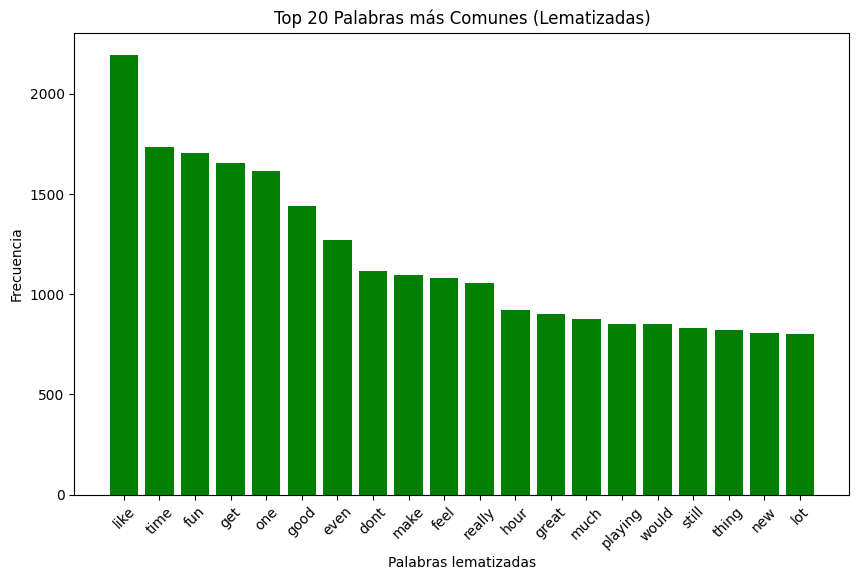

In [ ]:
# Importamos matplotlib para la visualización
import matplotlib.pyplot as plt

# Obtenemos las 20 palabras más comunes y sus frecuencias
palabras_lem, frecuencias_lem = zip(*frecuencia_palabras_lematizadas.most_common(20))

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))  # Ajustamos el tamaño del gráfico
plt.bar(palabras_lem, frecuencias_lem, color='green')

# Añadimos etiquetas y título
plt.xlabel('Palabras lematizadas')
plt.ylabel('Frecuencia')
plt.title('Top 20 Palabras más Comunes (Lematizadas)')

# Rotamos las etiquetas del eje X para que se lean mejor
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()

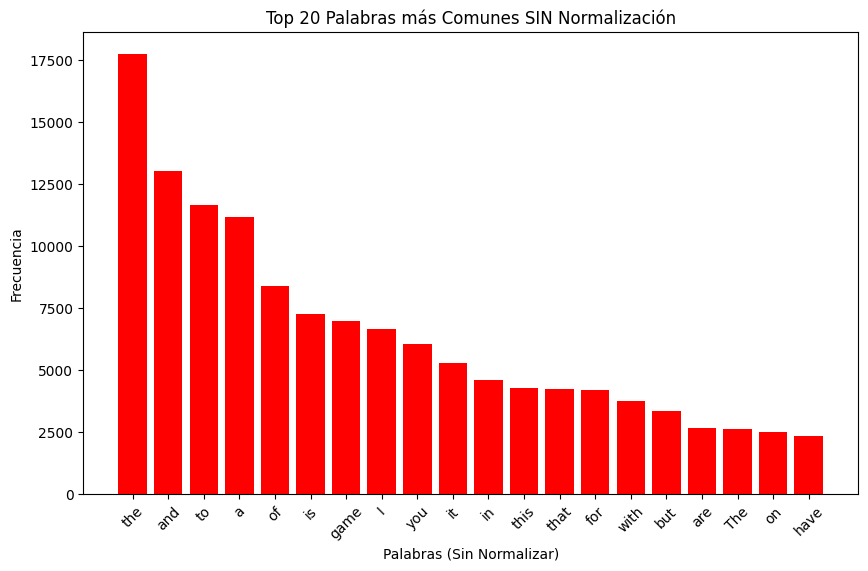

In [ ]:
# ¿Que hubiera pasado si creabamos este gráfico con los datos originales?
import matplotlib.pyplot as plt
from collections import Counter

# Tokenizamos sin normalizar (sin pasar a minúsculas, sin quitar puntuación)
tokens_sin_normalizar = [token for review in df_NLP['review'] for token in review.split()]

# Contamos la frecuencia de cada palabra
frecuencia_sin_normalizar = Counter(tokens_sin_normalizar)

# Obtenemos las 20 palabras más comunes y sus frecuencias
palabras_sin_norm, frecuencias_sin_norm = zip(*frecuencia_sin_normalizar.most_common(20))

# Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(palabras_sin_norm, frecuencias_sin_norm, color='red')  # Color rojo para marcar que está "mal"

# Añadimos etiquetas y título
plt.xlabel('Palabras (Sin Normalizar)')
plt.ylabel('Frecuencia')
plt.title('Top 20 Palabras más Comunes SIN Normalización')

# Rotamos las etiquetas del eje X para que se lean mejor
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()

# Nuves de palabras o WorldCloud

In [ ]:
# Importamos las librerías para crear una nube de palabras

from wordcloud import WordCloud
import matplotlib.pyplot as plt

/tmp/ipykernel_19515/2005870192.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



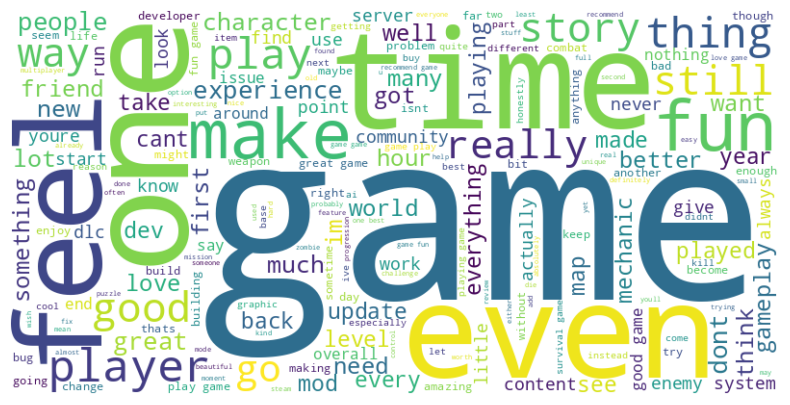

In [ ]:
# Unir todo el texto de la columna 'review_es'

#Esto es necesario porque la WordCloud genera la nube de palabras a partir de
# una única cadena de texto, y no puede procesar una columna de DataFrame directamente.

df_NLP['review_lematizacion_str'] = df_NLP['review_lematizacion'].apply(lambda x: " ".join(x))
text = " ".join(df_NLP['review_lematizacion_str'])

# Generar la WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
# Crea un objeto WordCloud con un ancho de 800 píxeles, altura de 400, y fondo blanco.
# El método 'generate' crea la nube de palabras a partir del texto dado.

# Mostrar la WordCloud
plt.figure(figsize=(10, 5))
# Crea una figura de tamaño 10x5 pulgadas para la visualización de la nube.

plt.imshow(wordcloud, interpolation='bilinear')
# Muestra la nube de palabras en la figura, usando interpolación bilineal para suavizarla.

plt.axis('off')
# Oculta los ejes de la figura para una mejor visualización.

plt.show()
# Muestra la figura en pantalla.

Accuracy: 0.8809766022380467

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77       297
           1       0.87      0.98      0.92       686

    accuracy                           0.88       983
   macro avg       0.90      0.82      0.84       983
weighted avg       0.89      0.88      0.87       983



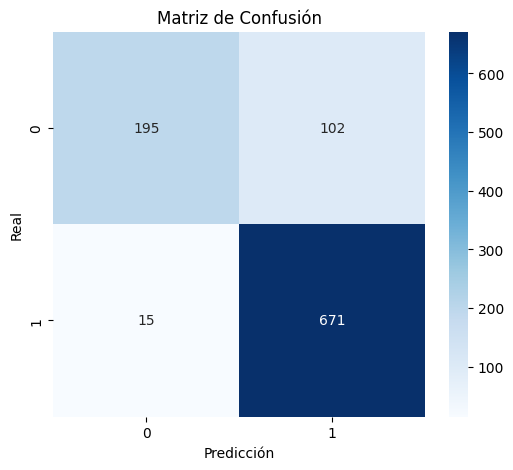

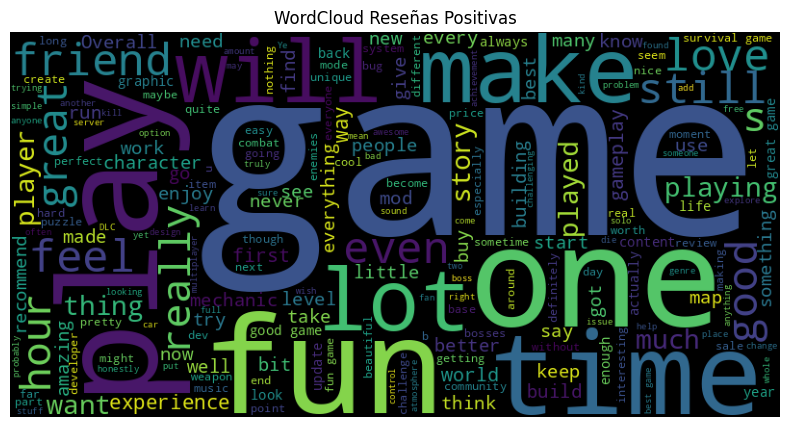

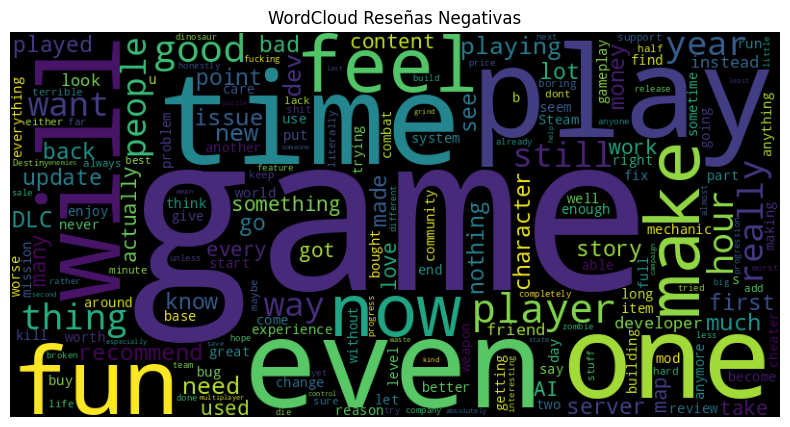

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Filtrado recomendado ---
df = df_NLP.copy()

df = df[df["review"].str.len() > 20]
df = df[df["steam_purchase"] == True]

# Convert 'weighted_vote_score' to numeric, coercing errors to NaN
df["weighted_vote_score"] = pd.to_numeric(df["weighted_vote_score"], errors='coerce')
# Now filter out NaNs and then apply the condition
df = df.dropna(subset=["weighted_vote_score"])
df = df[df["weighted_vote_score"] > 0]
df["review_lematizacion_str"] = df["review_lematizacion"].apply(lambda x: " ".join(x))

X = df["review_lematizacion_str"]
y = df["voted_up"].astype(int)

# --- 2. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. TF-IDF ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- 4. Modelo ---
model = LogisticRegression(max_iter=500)
model.fit(X_train_tfidf, y_train)

# --- 5. Predicciones ---
y_pred = model.predict(X_test_tfidf)

# --- 6. Métricas ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# --- 7. Matriz de confusión ---
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# --- 8. WordCloud Positivo ---
positive_reviews = " ".join(df[df["voted_up"]==1]["review"])
wordcloud_pos = WordCloud(width=800, height=400).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud Reseñas Positivas")
plt.show()

# --- 9. WordCloud Negativo ---
negative_reviews = " ".join(df[df["voted_up"]==0]["review"])
wordcloud_neg = WordCloud(width=800, height=400).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud Reseñas Negativas")
plt.show()

Despues del analisis se trato de sacar palabras tipicas como "game", "play" y demas

In [ ]:
df["review_lematizacion_str"] = df["review_lematizacion"].apply(lambda x: " ".join(x))

In [ ]:
positive_reviews = " ".join(df[df["voted_up"]==1]["review_lematizacion_str"])

In [ ]:
positive_text = " ".join(df[df["voted_up"]==1]["review"])

stopwords_wc = {"game", "play", "player"}

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_wc
).generate(positive_text)


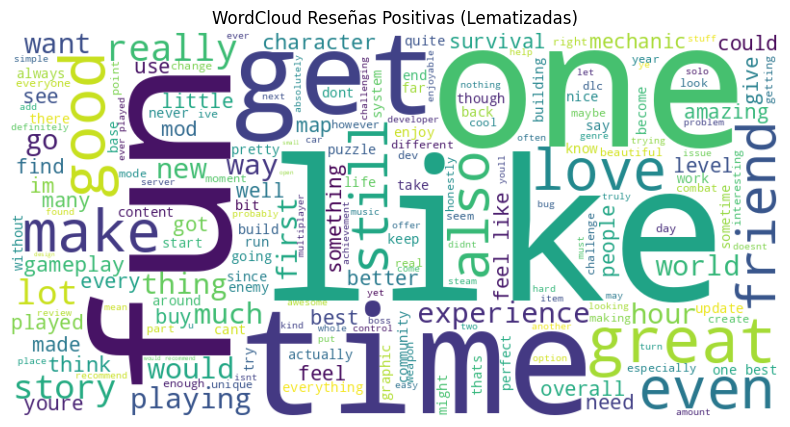

In [ ]:
positive_text = " ".join(df[df["voted_up"]==1]["review_lematizacion_str"])

stopwords_wc = {"game", "play", "player"}

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_wc
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Reseñas Positivas (Lematizadas)")
plt.show()

In [ ]:
negative_reviews = " ".join(df[df["voted_up"]==0]["review"])

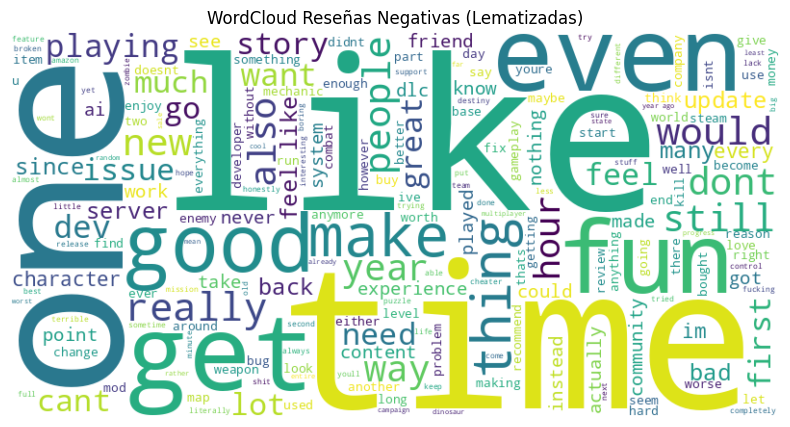

In [ ]:
negative_text = " ".join(df[df["voted_up"]==0]["review_lematizacion_str"])

stopwords_wc = {"game", "play", "player"}

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_wc
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Reseñas Negativas (Lematizadas)")
plt.show()

###Bigramas y Trigramas

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# ---------------------------
# BIGRAMAS
# ---------------------------
vectorizer_bi = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)

# Ajustamos y transformamos el texto
X_bi = vectorizer_bi.fit_transform(df_NLP['review_lematizacion_str'])

# Obtener palabras (bigramas)
bigrams = vectorizer_bi.get_feature_names_out()

# Frecuencias
freq_bi = X_bi.toarray().sum(axis=0)

# ---------------------------
# TRIGRAMAS
# ---------------------------
vectorizer_tri = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=20)

X_tri = vectorizer_tri.fit_transform(df_NLP['review_lematizacion_str'])

trigrams = vectorizer_tri.get_feature_names_out()
freq_tri = X_tri.toarray().sum(axis=0)
#Al final no lo uso porque no hay elementos interesantes en este apartado

In [ ]:
# Lista personalizada de palabras inútiles
custom_stopwords = ['game', 'like', 'bad', 'play']

In [ ]:
##Otra opcion sacando las palabras clae
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# Stopwords base + las tuyas
stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))

# Ejemplo con bigramas
vectorizer_bi = CountVectorizer(
    ngram_range=(2,2),
    stop_words=stop_words,
    max_features=20
)

X_bi = vectorizer_bi.fit_transform(df_NLP['review_lematizacion_str'])
bigrams = vectorizer_bi.get_feature_names_out()
freq_bi = X_bi.toarray().sum(axis=0)

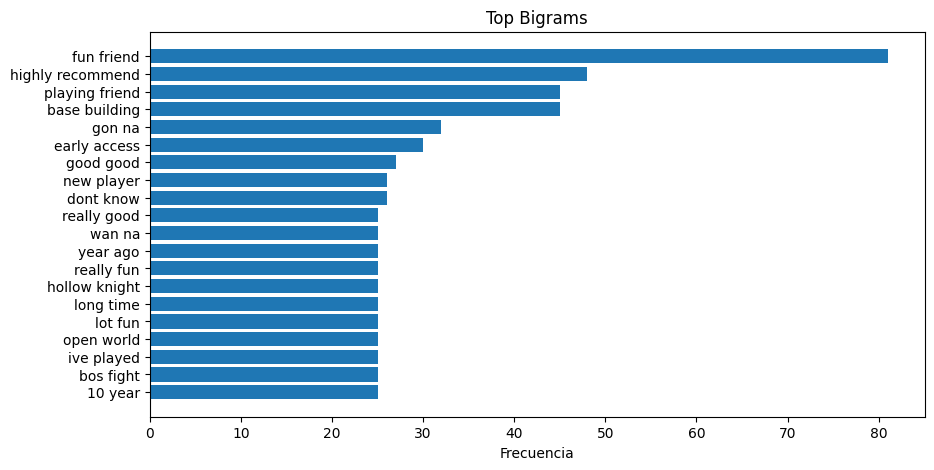

In [ ]:
import matplotlib.pyplot as plt

# Ordenamos por frecuencia
sorted_idx = freq_tri.argsort()

plt.figure(figsize=(10,5))
plt.barh(bigrams[sorted_idx], freq_tri[sorted_idx])
plt.title("Top Bigrams")
plt.xlabel("Frecuencia")
plt.show()

### Palabras de interes

En estos modelos de NLP analizamos las palabras unicas pero tambien en bigramas que son los mas interesantes del analisis (tambien si hizo con trigramas pero no se sacaron concluciones utiles por eso se an descartado).

Cuando se revisa con el ojo humano hay elementos interesantes aparte de las palabras tipicas como Early access y palabras relacioandas a jugar con amigos que analizaremos mas terde enla base final.

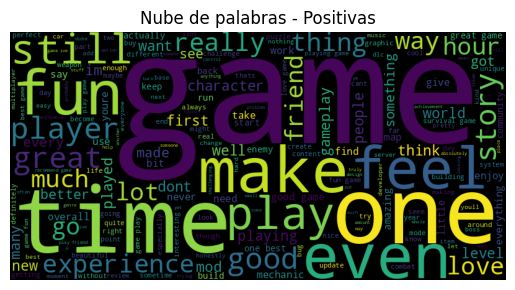

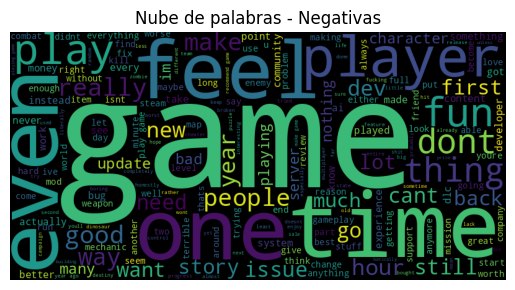

In [ ]:
from wordcloud import WordCloud

# Separar reseñas
positive_reviews = df_NLP[df_NLP['voted_up'] == 1]['review_lematizacion_str']
negative_reviews = df_NLP[df_NLP['voted_up'] == 0]['review_lematizacion_str']

# Unir texto
text_pos = " ".join(positive_reviews)
text_neg = " ".join(negative_reviews)

# ---------------------------
# WordCloud POSITIVO
# ---------------------------
wc_pos = WordCloud(width=800, height=400).generate(text_pos)

plt.imshow(wc_pos)
plt.axis("off")
plt.title("Nube de palabras - Positivas")
plt.show()

# ---------------------------
# WordCloud NEGATIVO
# ---------------------------
wc_neg = WordCloud(width=800, height=400).generate(text_neg)

plt.imshow(wc_neg)
plt.axis("off")
plt.title("Nube de palabras - Negativas")
plt.show()

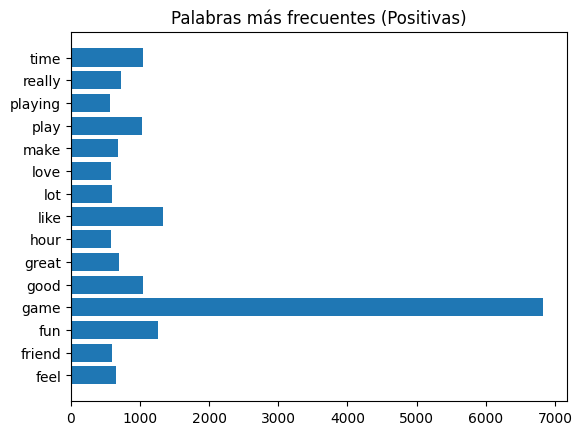

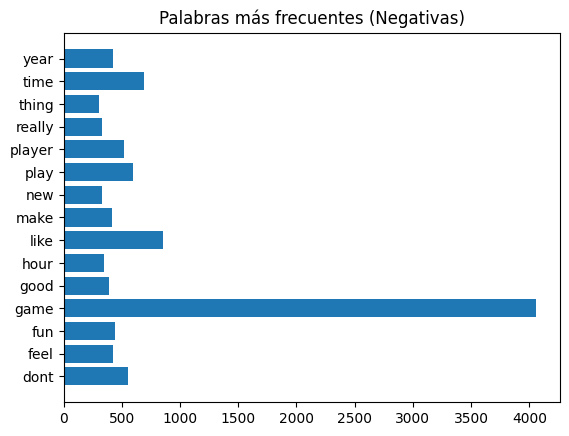

In [ ]:
# Usamos CountVectorizer para palabras individuales
vectorizer = CountVectorizer(stop_words='english', max_features=15)

# POSITIVAS
X_pos = vectorizer.fit_transform(positive_reviews)
words_pos = vectorizer.get_feature_names_out()
freq_pos = X_pos.toarray().sum(axis=0)

# NEGATIVAS
X_neg = vectorizer.fit_transform(negative_reviews)
words_neg = vectorizer.get_feature_names_out()
freq_neg = X_neg.toarray().sum(axis=0)

# Graficar positivas
plt.barh(words_pos, freq_pos)
plt.title("Palabras más frecuentes (Positivas)")
plt.show()

# Graficar negativas
plt.barh(words_neg, freq_neg)
plt.title("Palabras más frecuentes (Negativas)")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------
# Métricas
# ---------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.8809766022380467

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77       297
           1       0.87      0.98      0.92       686

    accuracy                           0.88       983
   macro avg       0.90      0.82      0.84       983
weighted avg       0.89      0.88      0.87       983



In [ ]:
X = df_NLP["review_lematizacion_str"]

##Elementos Adicionales

Agregar datos al nuesto dataset principal del data set donde tenia los graficos base

In [ ]:
df_NLP.loc[:, 'appid'] = df_NLP['appid'].astype(int)
dfData2.loc[:, 'Appid_del_Link'] = dfData2['Appid_del_Link'].astype(int)

In [ ]:
dfData2_subset = dfData2[
    [
        'Appid_del_Link',
        'Game Features',
        'Popular Tags',
        'Developer',
        'Game Description',
        'Recent Reviews Summary',
        'Jugadores_Actuales'
    ]
]

In [ ]:
df_merged = df_NLP.merge(
    dfData2_subset,
    left_on='appid',
    right_on='Appid_del_Link',
    how='left'  # importante: mantiene todas las reviews
)

In [ ]:
df_merged.head()

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,review_stemming,review_lematizacion,review_lematizacion_str,Appid_del_Link,Game Features,Popular Tags,Developer,Game Description,Recent Reviews Summary,Jugadores_Actuales
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,...,"[gambl, simul, cheater, gun, best, fp, game, d...","[gambling, simulator, cheater, gun, best, fps,...",gambling simulator cheater gun best fps game d...,730,"['Steam Achievements', 'Full controller suppor...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,...,"[click, head, satisfi, click, anyth, els, dog,...","[click, head, satisfying, click, anything, els...",click head satisfying click anything else dog ...,730,"['Steam Achievements', 'Full controller suppor...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,...,"[gold, gold, gold, love, gambl, open, one, cas...","[gold, gold, gold, love, gambling, open, one, ...",gold gold gold love gambling open one case don...,730,"['Steam Achievements', 'Full controller suppor...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,...,"[game, contain, way, mani, stupid, russian, at...","[game, contains, way, many, stupid, russian, a...",game contains way many stupid russian atleast ...,730,"['Steam Achievements', 'Full controller suppor...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,...,"[quotat, forthcom, edit, counterstrik, 2s, wal...","[quotation, forthcoming, edit, counterstrike, ...",quotation forthcoming edit counterstrike 2 wal...,730,"['Steam Achievements', 'Full controller suppor...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0


hacer Lematizacion de Game description

In [ ]:
#  Es útil para normalizar texto antes de analizarlo o procesarlo.
df_merged['GD_lower'] = df_merged['Game Description'].apply(lambda text: text.lower())

In [ ]:
import re

# Definir una función que remueva los signos de puntuación usando re
def remove_punctuation(text):
    # Expresión regular para reemplazar cualquier signo de puntuación o símbolo no alfanumérico
     return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Aplicar la función a la columna 'review_lower'
df_merged['GD_puntuacion'] = df_merged['GD_lower'].apply(remove_punctuation)

In [ ]:
# Tokenizamos los valores de la columna 'review'
df_merged['GD_tokenizado'] = df_merged['GD_puntuacion'] .apply(word_tokenize)


In [ ]:
# Configuramos pandas para mostrar el contenido completo de las columnas
pd.set_option('display.max_colwidth', None)

In [ ]:
# Mostramos las primeras filas con la columna original y de la columna tokenizada
df_merged[['Game Description', 'GD_tokenizado']].head(2)

,Game Description,GD_tokenizado
0,"Counter-Strike: Global Offensive (CS: GO) expands upon the team-based action gameplay that it pioneered when it was launched 19 years ago. CS: GO features new maps, characters, weapons, and game modes, and delivers updated versions of the classic CS content (de_dust2, etc.).","[counterstrike, global, offensive, cs, go, expands, upon, the, teambased, action, gameplay, that, it, pioneered, when, it, was, launched, 19, years, ago, cs, go, features, new, maps, characters, weapons, and, game, modes, and, delivers, updated, versions, of, the, classic, cs, content, dedust2, etc]"
1,"Counter-Strike: Global Offensive (CS: GO) expands upon the team-based action gameplay that it pioneered when it was launched 19 years ago. CS: GO features new maps, characters, weapons, and game modes, and delivers updated versions of the classic CS content (de_dust2, etc.).","[counterstrike, global, offensive, cs, go, expands, upon, the, teambased, action, gameplay, that, it, pioneered, when, it, was, launched, 19, years, ago, cs, go, features, new, maps, characters, weapons, and, game, modes, and, delivers, updated, versions, of, the, classic, cs, content, dedust2, etc]"


In [ ]:
# Restauramos la configuración predeterminada de pandas para el ancho de las columnas
pd.reset_option('display.max_colwidth')

## Quitar las Stopword o palabras conectoras

In [ ]:
# Previsualizamos algunas stopwords previstas en la librería.

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Obtenemos el listado de stopwords en español
stopwords_eng = stopwords.words('english')

# Mostramos las primeras 20
print(stopwords_eng[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Importamos stopwords de NLTK (Pueden importarse tanto para español como para inglés)
nltk.download('stopwords') # Descargamos el paquete de stopwords de NLTK para poder usarlas en el código
from nltk.corpus import stopwords # Importamos el módulo de stopwords desde NLTK, que contiene listas de palabras vacías

# Lista de stopwords en inglés
stop_words = set(stopwords.words('english')) # Creamos un conjunto de stopwords en inglés usando NLTK

# Función para eliminar stopwords de los tokens
# Aplicamos una función lambda a cada fila de la columna 'review_tokenizado'
df_merged['GD_tokenizado_sin_stopwords'] = df_merged['GD_tokenizado'].apply(lambda tokens: [word for word in tokens if word not in stop_words])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


El uso de palabras cortadas

In [ ]:
# Importar el PorterStemmer de nltk
from nltk.stem import PorterStemmer

# Inicializar el stemmer
stemmer = PorterStemmer()

# Aplicar stemming a la columna 'review_tokenizado_sin_stopwords'
df_merged['GD_stemming'] = df_merged['GD_tokenizado_sin_stopwords'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])


In [ ]:
#Importamos librerías

import nltk
nltk.download('wordnet')  # Base de datos léxica de WordNet para lematización en inglés

# Importar el WordNetLemmatizer de nltk
from nltk.stem import WordNetLemmatizer

# Inicializar el lematizador
lemmatizer = WordNetLemmatizer()

# Aplicar la lematización a la columna 'review_tokenizado_sin_stopwords'
df_merged['GD_lematizacion'] = df_merged['GD_tokenizado_sin_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df_merged.head(15)

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,Developer,Game Description,Recent Reviews Summary,Jugadores_Actuales,GD_lower,GD_puntuacion,GD_tokenizado,GD_tokenizado_sin_stopwords,GD_stemming,GD_lematizacion
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expand,...","[counterstrike, global, offensive, c, go, expa..."
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expand,...","[counterstrike, global, offensive, c, go, expa..."
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expand,...","[counterstrike, global, offensive, c, go, expa..."
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expand,...","[counterstrike, global, offensive, c, go, expa..."
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expand,...","[counterstrike, global, offensive, c, go, expa..."
5,212041886,"{'steamid': '76561199797065377', 'num_games_ow...",english,1764525066,1764525066,True,22,12,0.679784,5,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expand,...","[counterstrike, global, offensive, c, go, expa..."
6,209851015,"{'steamid': '76561199038041256', 'num_games_ow...",english,1763824239,1763824239,True,25,5,0.672832,2,...,"Valve, Hidden Path Entertainment",Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,1014674.0,counter-strike: global offensive (cs: go) expa...,counterstrike global offensive cs go expands u...,"[counterstrike, global, offensive, cs, go, exp...","[counterstrike, global, offensive, cs, go, exp...","[counterstrik, global, offens, cs, go, expan

In [ ]:
#Eliminar lo inicesario
df_merged.drop(
    columns=[
        'GD_lower',
        'GD_puntuacion',
        'GD_tokenizado',
        'GD_tokenizado_sin_stopwords',
        'GD_stemming',
        'review_lower'
    ],
    errors='ignore',
    inplace=True
)

In [ ]:
df_merged.columns

Index(['recommendationid', 'author', 'language', 'timestamp_created',
       'timestamp_updated', 'voted_up', 'votes_up', 'votes_funny',
       'weighted_vote_score', 'comment_count', 'steam_purchase',
       'received_for_free', 'written_during_early_access',
       'primarily_steam_deck', 'appid', 'timestamp_dev_responded',
       'developer_response', 'review', 'review_puntuacion',
       'review_tokenizado', 'review_tokenizado_sin_stopwords',
       'review_stemming', 'review_lematizacion', 'review_lematizacion_str',
       'Appid_del_Link', 'Game Features', 'Popular Tags', 'Developer',
       'Game Description', 'Recent Reviews Summary', 'Jugadores_Actuales',
       'GD_lematizacion'],
      dtype='object')

In [ ]:
#Backup por si acaso
df_backup = df_merged.copy()

In [ ]:
# Importamos librerías necesarias
import pandas as pd

# Nos aseguramos de que no haya valores nulos en las columnas clave
df_merged['review_lematizacion'] = df_merged['review_lematizacion'].fillna('')
df_merged['GD_lematizacion'] = df_merged['GD_lematizacion'].fillna('')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join lists of tokens into single strings for each column
df_merged['review_lematizacion_str'] = df_merged['review_lematizacion'].apply(lambda x: ' '.join(x))
df_merged['GD_lematizacion_str'] = df_merged['GD_lematizacion'].apply(lambda x: ' '.join(x))

# Unimos ambos textos para que compartan el mismo vocabulario
corpus = df_merged['review_lematizacion_str'].tolist() + df_merged['GD_lematizacion_str'].tolist()

# Creamos el vectorizador
tfidf = TfidfVectorizer(max_features=5000)

# Entrenamos con TODO el corpus (esto es correcto en este caso)
tfidf.fit(corpus)

# Transformamos cada parte por separado
tfidf_review = tfidf.transform(df_merged['review_lematizacion_str'])
tfidf_desc = tfidf.transform(df_merged['GD_lematizacion_str'])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calculamos la similitud fila a fila
# (review i con descripción i)
similarities = []

for i in range(tfidf_review.shape[0]):
    sim = cosine_similarity(tfidf_review[i], tfidf_desc[i])[0][0]
    similarities.append(sim)

# Guardamos como nueva feature
df_merged['review_desc_similarity'] = similarities

#Analisis de Sentimiento

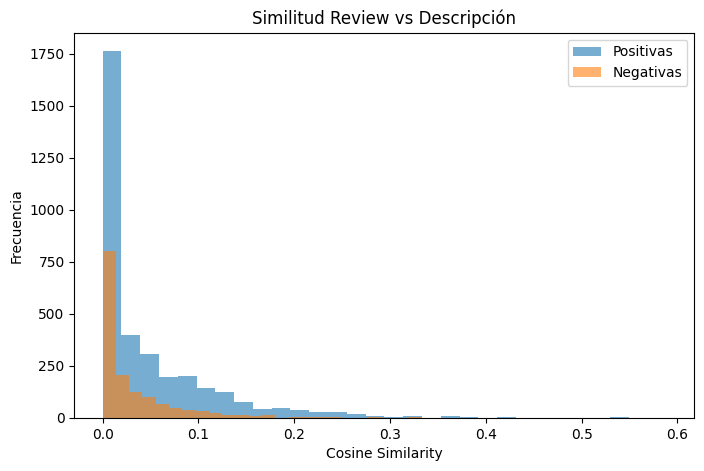

In [ ]:
import matplotlib.pyplot as plt

# Separamos por sentimiento
positive = df_merged[df_merged['voted_up'] == 1]['review_desc_similarity']
negative = df_merged[df_merged['voted_up'] == 0]['review_desc_similarity']

# Graficamos distribución
plt.figure(figsize=(8,5))

plt.hist(positive, bins=30, alpha=0.6, label='Positivas')
plt.hist(negative, bins=30, alpha=0.6, label='Negativas')

plt.title('Similitud Review vs Descripción')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

In [ ]:
print("Similitud promedio (positivas):", positive.mean())
print("Similitud promedio (negativas):", negative.mean())

Similitud promedio (positivas): 0.046571947836292066
Similitud promedio (negativas): 0.030036377467868754


## **Resultados del Análisis de Sentimientos y Pruebas de NLP**

En la valoración cualitativa de las reseñas, el análisis basado en texto lematizado permitió identificar las palabras más frecuentes dentro del corpus. Entre ellas destacan términos como *“like”, “time” y “fun”*, lo que evidencia que **la experiencia lúdica y la inversión** de tiempo constituyen factores centrales en la percepción del usuario.

No obstante, estos resultados también ponen de manifiesto una limitación metodológica relevante: la alta frecuencia de ciertas palabras puede responder más a su uso generalizado en el lenguaje que a su verdadero peso semántico. Por este motivo, se vuelve fundamental complementar el análisis automatizado investigado de forma conciente por una persona para que al final pueda sacar concluciones relevantes en una revisión manual, permitiendo filtrar términos de bajo valor analítico y mejorar la interpretación de los resultados.

Dentro de los hallazgos **más significativos**, se observa una fuerte presencia del término *"early access”*, particularmente asociado a reseñas positivas. Esto sugiere que los usuarios valoran la posibilidad de acceder anticipadamente a los productos, especialmente cuando esta modalidad se orienta a la construcción de comunidad y participación activa, más que a una simple instancia de testeo. En este sentido, el acceso anticipado puede constituir una **práctica que agrega valor percibido cuando está correctamente implementada**.

Asimismo, emergen conceptos vinculados a la experiencia social del videojuego, como *“fun frienly”, “friendly” o “new player”*. Estos términos reflejan la importancia de los componentes multijugador, cooperativos y de accesibilidad, indicando que la interacción con otros usuarios y la facilidad de ingreso para nuevos jugadores son factores que contribuyen positivamente a la valoración general.

## **Importancia del Procesamiento y la Calidad de los Datos**

El desarrollo del análisis pone en evidencia la relevancia crítica de las etapas de **normalización y limpieza de datos**. La eliminación de signos de puntuación, palabras vacías (stopwords) y ruido lingüístico resulta esencial para evitar que términos irrelevantes —como “the”, “and” o “to”— dominen las métricas de frecuencia y distorsionen los resultados.

Por otro lado, a partir de la integración de métricas cuantitativas y visualizaciones, se pueden inferir patrones relacionados con la **consistencia y el ciclo de vida de los videojuegos**. Si bien esta observación es de carácter exploratorio, los datos sugieren que la permanencia de un título en el tiempo depende en **gran medida de su capacidad para sostener el interés más allá del lanzamiento inicial**, ya sea mediante contenido continuo o a través de un game loop sólido.

###Este comportamiento varía según el tipo de producto:

*   En juegos como servicio o títulos competitivos, el éxito está asociado a la retención y actividad constante de los jugadores.
*   En juegos narrativos o de experiencia cerrada, es más común observar un pico inicial de adopción seguido de una estabilización en el tiempo.

Aunque no se dispone de datos directos sobre ventas —debido a la naturaleza sensible de esta información—, los patrones observados permiten inferir que los títulos con mayor impacto logran concentrar un volumen significativo de jugadores en sus etapas iniciales, destacándose dentro del dataset analizado.

In [ ]:
#Vamos a usar Spacy
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

# Cargamos modelo en inglés
nlp = spacy.load("en_core_web_sm")

In [ ]:
df_merged['review_lematizacion']

,review_lematizacion
0,"[gambling, simulator, cheater, gun, best, fps,..."
1,"[click, head, satisfying, click, anything, els..."
2,"[gold, gold, gold, love, gambling, open, one, ..."
3,"[game, contains, way, many, stupid, russian, a..."
4,"[quotation, forthcoming, edit, counterstrike, ..."
...,...
4950,"[like, centipede, bad, bad, meaning, bad, bad,..."
4951,"[sorta, like, space, invader, bit, complex]"
4952,"[shortlivedlike, caterpillar, shoe, bad]"
4953,"[nerdcame, hard, reason]"


In [ ]:
# Función para filtrar tokens útiles
def spacy_filter(text):
    doc = nlp(text)

    tokens = []
    for token in doc:
        # Nos quedamos con palabras útiles
        if not token.is_stop and not token.is_punct:
            tokens.append(token.text)

    return " ".join(tokens)

# Aplicamos
df_merged['review_spacy_clean'] = df_merged['review_lematizacion_str'].apply(spacy_filter)

In [ ]:
def extract_pos_features(text):
    doc = nlp(text)

    nouns = sum(1 for token in doc if token.pos_ == "NOUN")
    verbs = sum(1 for token in doc if token.pos_ == "VERB")
    adjs = sum(1 for token in doc if token.pos_ == "ADJ")

    return pd.Series([nouns, verbs, adjs])

df_merged[['n_nouns', 'n_verbs', 'n_adjs']] = df_merged['review_lematizacion_str'].apply(extract_pos_features)

In [ ]:
df_merged['review_length'] = df_merged['review_lematizacion_str'].apply(len)

In [ ]:
#reconocimiento de titulo
def extract_entities(text):
    doc = nlp(text)
    return len(doc.ents)

df_merged['n_entities'] = df_merged['review_lematizacion_str'].apply(extract_entities)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_text = tfidf.fit_transform(df_merged['review_spacy_clean'])

In [ ]:
import numpy as np
from scipy.sparse import hstack

# Features numéricas
X_numeric = df_merged[['n_nouns', 'n_verbs', 'n_adjs', 'review_length', 'n_entities']].values

# Combinar
X_final = hstack([X_text, X_numeric])

# Target
y = df_merged['voted_up']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8849646821392533


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [ ]:
df_merged.groupby('voted_up')[['n_adjs','n_verbs']].mean()

,n_adjs,n_verbs
voted_up,,
False,8.710231,13.326073
True,7.044477,8.519767


In [ ]:
import spacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

In [ ]:
def classify_review(text):
    doc = nlp(text.lower())

    text_lower = text.lower()

    # 🔹 Regla 1: Recomendación
    if "recommend" in text_lower or "you should" in text_lower:
        return "recommendation"

    # 🔹 Regla 2: Queja
    if any(word in text_lower for word in ["bad", "terrible", "cheater", "bug", "broken"]):
        return "complaint"

    # 🔹 Regla 3: Meme / humor
    if any(word in text_lower for word in ["lol", "haha", "xd", "funny"]):
        return "humor"

    # 🔹 Regla 4: Opinión (default)
    return "opinion"

In [ ]:
df_merged['review_type'] = df_merged['review_lematizacion_str'].apply(classify_review)

In [ ]:
df_merged['review_type'].value_counts()

,count
review_type,
opinion,3543
recommendation,730
complaint,603
humor,79


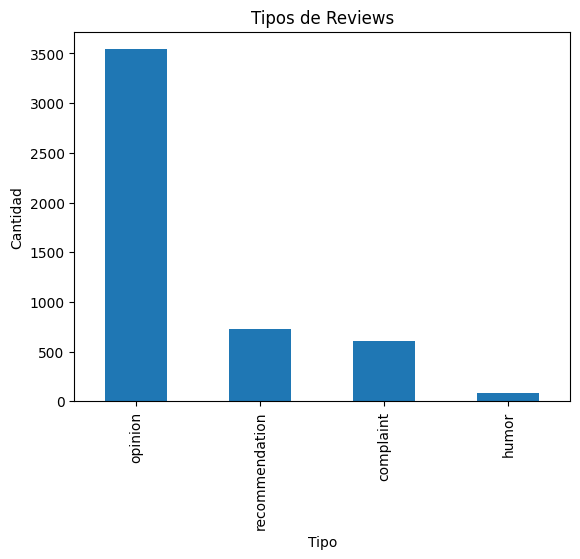

In [ ]:
import matplotlib.pyplot as plt

df_merged['review_type'].value_counts().plot(kind='bar')

plt.title("Tipos de Reviews")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")

plt.show()

In [ ]:
pd.crosstab(df_merged['review_type'], df_merged['voted_up'])

voted_up,False,True
review_type,,
complaint,346,257
humor,16,63
opinion,923,2620
recommendation,230,500


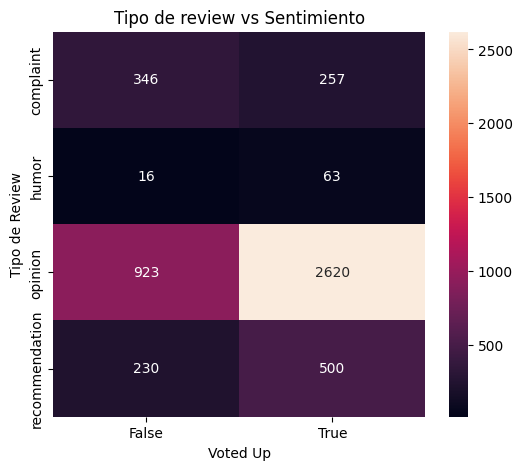

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    pd.crosstab(df_merged['review_type'], df_merged['voted_up']),
    annot=True,
    fmt='d'
)

plt.title("Tipo de review vs Sentimiento")
plt.xlabel("Voted Up")
plt.ylabel("Tipo de Review")

plt.show()

## **Spacy y concluciones**

Al trabajar con spaCy, pude organizar y clasificar mejor la información del dataset, asignando una estructura más clara a los datos. Este proceso me permitió generar una referencia útil para el análisis, facilitando algo clave en la interpretación humana: entender a qué categoría pertenece cada tipo de contenido.

Gracias a esto, fue posible distinguir con mayor precisión entre datos relevantes, opiniones, y casos más ambiguos como el sarcasmo o el humor. Esta diferenciación aporta una base más sólida para el análisis, ya que permite identificar qué elementos tienen mayor peso y cuáles pueden distorsionar las conclusiones si no se interpretan correctamente.

En definitiva, este enfoque mejora la calidad del análisis final, al combinar el procesamiento automático con una lectura más consciente y contextual de los datos.

# **Síntesis del Análisis**

En conjunto, el proyecto integra de manera efectiva técnicas de **análisis cuantitativo** (métricas, tendencias y comportamiento de usuarios) y **análisis cualitativo** (procesamiento de lenguaje natural y sentimiento), permitiendo construir una visión más completa sobre los factores que influyen en la percepción y el desempeño de los videojuegos dentro del mercado.

##TF-IDF

In [ ]:
from scipy.sparse import hstack

# Convertimos la similitud en formato compatible
sim_feature = np.array(df_merged['review_desc_similarity']).reshape(-1,1)

# Combinamos TF-IDF + similitud
X_combined = hstack([tfidf_review, sim_feature])

# Target
y = df_merged['voted_up']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

# Modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluación
accuracy = model.score(X_test, y_test)
print("Accuracy con similitud:", accuracy)

Accuracy con similitud: 0.8970736629667003


#**TF-IDF Entrenamiento de seguimiento**

In [ ]:
df_NLP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   recommendationid                 4955 non-null   int64  
 1   author                           4955 non-null   object 
 2   language                         4955 non-null   object 
 3   timestamp_created                4955 non-null   int64  
 4   timestamp_updated                4955 non-null   int64  
 5   voted_up                         4955 non-null   bool   
 6   votes_up                         4955 non-null   int64  
 7   votes_funny                      4955 non-null   int64  
 8   weighted_vote_score              4955 non-null   float64
 9   comment_count                    4955 non-null   int64  
 10  steam_purchase                   4955 non-null   bool   
 11  received_for_free                4955 non-null   bool   
 12  written_during_early

In [ ]:
dfData2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18375 entries, 0 to 18374
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID_juego                  18375 non-null  int64         
 1   Title                     18370 non-null  object        
 2   Original Price            18375 non-null  object        
 3   Discounted Price          18375 non-null  float64       
 4   Release Date              18375 non-null  datetime64[ns]
 5   Link                      18375 non-null  object        
 6   Game Description          18373 non-null  object        
 7   Recent Reviews Summary    18375 non-null  object        
 8   All Reviews Summary       18168 non-null  object        
 9   Recent Reviews Number     18371 non-null  object        
 10  All Reviews Number        4477 non-null   object        
 11  Developer                 18342 non-null  object        
 12  Publisher         

In [ ]:
df_NLP.head()

,recommendationid,author,language,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,timestamp_dev_responded,developer_response,review,review_lower,review_puntuacion,review_tokenizado,review_tokenizado_sin_stopwords,review_stemming,review_lematizacion,review_lematizacion_str
0,208778276,"{'steamid': '76561198769955331', 'num_games_ow...",english,1762666445,1763957182,True,485,135,0.913510,23,...,NaN,NaN,Gambling simulator with cheaters and guns! Bes...,gambling simulator with cheaters and guns! bes...,gambling simulator with cheaters and guns best...,"[gambling, simulator, with, cheaters, and, gun...","[gambling, simulator, cheaters, guns, best, fp...","[gambl, simul, cheater, gun, best, fp, game, d...","[gambling, simulator, cheater, gun, best, fps,...",gambling simulator cheater gun best fps game d...
1,211640921,"{'steamid': '76561198081237360', 'num_games_ow...",english,1764421285,1764421285,True,69,17,0.838050,9,...,NaN,NaN,Click heads = satisfying . \r\nClick anything ...,click heads = satisfying . \r\nclick anything ...,click heads satisfying \r\nclick anything el...,"[click, heads, satisfying, click, anything, el...","[click, heads, satisfying, click, anything, el...","[click, head, satisfi, click, anyth, els, dog,...","[click, head, satisfying, click, anything, els...",click head satisfying click anything else dog ...
2,211128320,"{'steamid': '76561199251091395', 'num_games_ow...",english,1764240795,1764240795,True,47,11,0.762419,9,...,NaN,NaN,gold gold gold!\ni love gambling but if i open...,gold gold gold!\ni love gambling but if i open...,gold gold gold\ni love gambling but if i open ...,"[gold, gold, gold, i, love, gambling, but, if,...","[gold, gold, gold, love, gambling, open, one, ...","[gold, gold, gold, love, gambl, open, one, cas...","[gold, gold, gold, love, gambling, open, one, ...",gold gold gold love gambling open one case don...
3,209783078,"{'steamid': '76561199471545860', 'num_games_ow...",english,1763749266,1763749266,True,45,9,0.727317,0,...,NaN,NaN,this game contains way too many stupid russian...,this game contains way too many stupid russian...,this game contains way too many stupid russian...,"[this, game, contains, way, too, many, stupid,...","[game, contains, way, many, stupid, russians, ...","[game, contain, way, mani, stupid, russian, at...","[game, contains, way, many, stupid, russian, a...",game contains way many stupid russian atleast ...
4,208642194,"{'steamid': '76561198770614871', 'num_games_ow...",english,1762533011,1764941428,True,19,0,0.680331,1,...,NaN,NaN,Quotation forthcoming.\n\nEDIT:\n\nCounter-Str...,quotation forthcoming.\n\nedit:\n\ncounter-str...,quotation forthcoming\n\nedit\n\ncounterstrike...,"[quotation, forthcoming, edit, counterstrike, ...","[quotation, forthcoming, edit, counterstrike, ...","[quotat, forthcom, edit, counterstrik, 2s, wal...","[quotation, forthcoming, edit, counterstrike, ...",quotation forthcoming edit counterstrike 2 wal...


In [ ]:
## Mas tarde ahore pruebas combinado info de los dos data set
#tener presente que ahora quiero hacer algo facil para practicar y despues complicarlo

In [ ]:
#Volvamos a limpiar las Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df_NLP['review_lematizacion_str'])

In [ ]:
#Implementacion de TF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df_NLP['review_lematizacion_str'])

In [ ]:
# Modelo

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df_NLP['voted_up'], test_size=0.2
)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(accuracy)

0.8799192734611504


##Relevancia del TF-IDF en la investigacion.

La implementación de la técnica **TF-IDF (Term Frequency – Inverse Document Frequency)** se consolidó como un componente crítico dentro del pipeline de procesamiento, trascendiendo su rol como simple requisito técnico. A diferencia de los enfoques basados en conteo de frecuencias absolutas, que tienden a resaltar términos de bajo valor semántico como “the” o “and”, el TF-IDF permite ponderar la importancia relativa de las palabras dentro del corpus, priorizando aquellas con mayor capacidad descriptiva.

Gracias a esta metodología, fue posible **destacar términos** con mayor carga semántica —como *“fun”, “story” o “issues”*—, facilitando una representación más significativa del contenido textual. Este enfoque permitió mejorar sustancialmente el desempeño de los modelos de clasificación.

En particular, la aplicación de TF-IDF como técnica de vectorización contribuyó a que un modelo de **Regresión Logística** alcanzara una precisión aproximada del **88%**, evidenciando que la correcta identificación y ponderación de términos relevantes constituye un factor determinante para comprender los elementos que influyen en la recomendación de un videojuego por parte de los usuarios.

En síntesis, el uso de TF-IDF no solo optimiza la calidad de los datos de entrada, sino que también potencia la capacidad explicativa y predictiva de los modelos, consolidándose como una herramienta fundamental en el análisis de texto dentro del dominio de reseñas.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df_NLP['review_lematizacion_str'])

sequences = tokenizer.texts_to_sequences(df_NLP['review_lematizacion_str'])
X_seq = pad_sequences(sequences, maxlen=100)

In [ ]:
#Prueba de forma dos para tener el X_seq y tomar todos mis datos en lugar de los entrenados

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    df_NLP['voted_up'],
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [ ]:
#history = model.fit(
#    X_train,
#    y_train,
#    epochs=15,
#    batch_size=64,
#    validation_data=(X_test, y_test)
#)

TypeError: LogisticRegression.fit() got an unexpected keyword argument 'epochs'

In [ ]:
#model.evaluate(X_test, y_test)

In [ ]:
##modelo original para hacer TF

## Modelo LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_seq, df_NLP['voted_up'], epochs=15, batch_size=32 , validation_split=0.1)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7869 - loss: 0.4493 - val_accuracy: 0.7903 - val_loss: 0.4755
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9419 - loss: 0.1687 - val_accuracy: 0.7722 - val_loss: 0.5449
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9673 - loss: 0.1002 - val_accuracy: 0.7742 - val_loss: 0.5998
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9827 - loss: 0.0616 - val_accuracy: 0.8004 - val_loss: 0.7343
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9906 - loss: 0.0338 - val_accuracy: 0.7903 - val_loss: 0.7684
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9971 - loss: 0.0157 - val_accuracy: 0.8065 - val_loss: 0.8799
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.9980 - loss: 0.0126 - val_accuracy: 0.7863 - val_loss: 0.9283
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9984 - loss: 0.0095 - val_accuracy: 0.

In [ ]:
X_seq

array([[   0,    0,    0, ...,  376, 2145,   95],
       [   0,    0,    0, ...,  321, 2146,    1],
       [   0,    0,    0, ...,   34, 1788, 2732],
       ...,
       [   0,    0,    0, ..., 3980, 4116,   63],
       [   0,    0,    0, ...,    0,   89,  181],
       [  32,    1,  100, ..., 1640, 1028,  795]], dtype=int32)

### Testeo de resultados

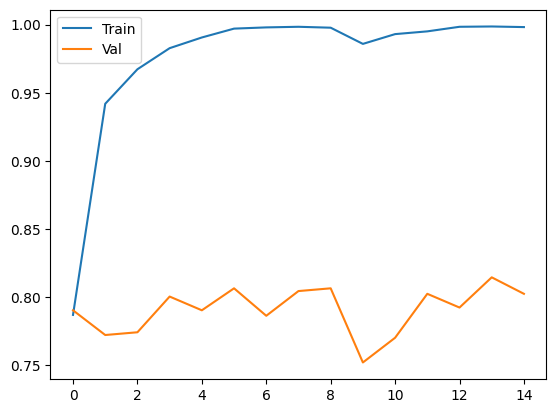

In [ ]:
# Visualización de la precisión de entrenamiento y validación durante el entrenamiento
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.show()

# En el eje de las abscisas (x) observamos las épocas y en ordenadas (y) el accuracy del modelo.

In [ ]:
# Evalúa el modelo con los datos de prueba y devuelve pérdida y precisión
score = model.evaluate(X_test, y_test, verbose=0)

# Muestra los resultados en el conjunto de prueba
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.08929302543401718
Test accuracy: 0.9818365573883057


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


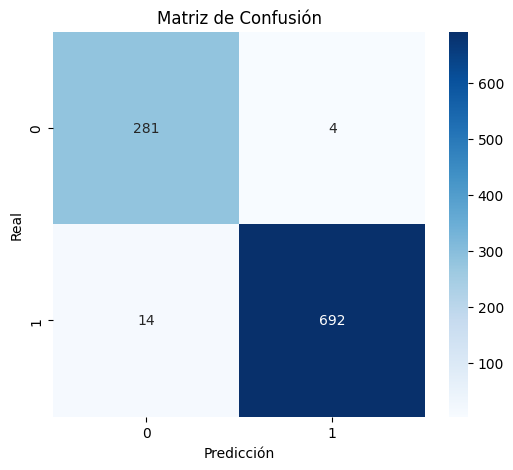

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predicciones
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Matriz
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicción del modelo: 0
Probabilidad de ser positiva: 0.01%
Probabilidad de ser negativa: 99.99%


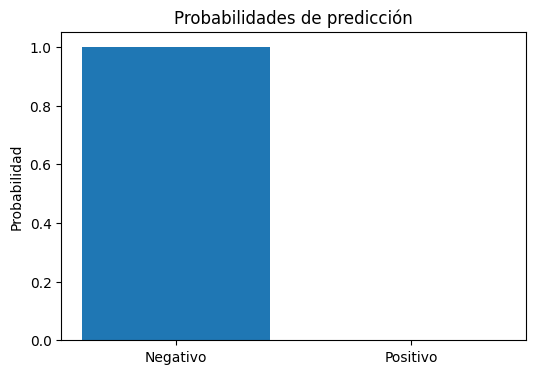

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Elegimos una muestra
sample = X_test[0].reshape(1, -1)

# Predicción
pred = model.predict(sample)[0][0]

# Clase
clase_predicha = 1 if pred > 0.5 else 0

print(f"Predicción del modelo: {clase_predicha}")
print(f"Probabilidad de ser positiva: {pred*100:.2f}%")
print(f"Probabilidad de ser negativa: {(1-pred)*100:.2f}%")

# Gráfico
plt.figure(figsize=(6,4))
plt.bar(['Negativo', 'Positivo'], [1-pred, pred])
plt.title("Probabilidades de predicción")
plt.ylabel("Probabilidad")
plt.show()

##RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential()

# Embedding
model_rnn.add(Embedding(input_dim=5000, output_dim=64, input_length=100))

# RNN simple
model_rnn.add(SimpleRNN(64))

# Salida
model_rnn.add(Dense(1, activation='sigmoid'))

# Compilación
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenamiento
history_rnn = model_rnn.fit(
    X_seq,
    df_NLP['voted_up'],
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7578 - loss: 0.5240 - val_accuracy: 0.6875 - val_loss: 0.5850
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9435 - loss: 0.1646 - val_accuracy: 0.7863 - val_loss: 0.5035
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9868 - loss: 0.0462 - val_accuracy: 0.7399 - val_loss: 0.6541
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9962 - loss: 0.0215 - val_accuracy: 0.7681 - val_loss: 0.7131
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9980 - loss: 0.0109 - val_accuracy: 0.7540 - val_loss: 0.7776
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9980 - loss: 0.0083 - val_accuracy: 0.7601 - val_loss: 0.8375
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.7722 - val_loss: 0.8063
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9987 - loss: 0.0060 - val_accuracy: 0.782

## CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

model_cnn = Sequential()

# Embedding
model_cnn.add(Embedding(input_dim=5000, output_dim=64, input_length=100))

# Convolución
model_cnn.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Pooling
model_cnn.add(GlobalMaxPooling1D())

# Salida
model_cnn.add(Dense(1, activation='sigmoid'))

# Compilación
model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenamiento
history_cnn = model_cnn.fit(
    X_seq,
    df_NLP['voted_up'],
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7309 - loss: 0.5379 - val_accuracy: 0.8065 - val_loss: 0.4201
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9208 - loss: 0.2122 - val_accuracy: 0.8004 - val_loss: 0.4343
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9758 - loss: 0.0859 - val_accuracy: 0.8125 - val_loss: 0.4892
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9935 - loss: 0.0358 - val_accuracy: 0.8004 - val_loss: 0.5536
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9971 - loss: 0.0171 - val_accuracy: 0.8085 - val_loss: 0.5674
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9982 - loss: 0.0094 - val_accuracy: 0.8105 - val_loss: 0.6321
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9987 - loss: 0.0073 - val_accuracy: 0.7863 - val_loss: 0.6979
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9987 - loss: 0.0061 - val_accu

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# Generamos predicciones
# ---------------------------

# model.predict devuelve probabilidades (0 a 1)
# Convertimos a clases (0 o 1) usando umbral 0.5

y_pred_lstm = (model.predict(X_seq) > 0.5).astype("int32")
y_pred_rnn = (model_rnn.predict(X_seq) > 0.5).astype("int32")
y_pred_cnn = (model_cnn.predict(X_seq) > 0.5).astype("int32")

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


In [ ]:
df_NLP['voted_up'].value_counts()

,count
voted_up,
True,3440
False,1515


In [ ]:
##Parece ser que tengo un desbalance en mis datos

In [ ]:
# ---------------------------
# Mostramos métricas detalladas
# ---------------------------

print("===== LSTM =====")
print(classification_report(df_NLP['voted_up'], y_pred_lstm))

print("===== RNN =====")
print(classification_report(df_NLP['voted_up'], y_pred_rnn))

print("===== CNN =====")
print(classification_report(df_NLP['voted_up'], y_pred_cnn))

===== LSTM =====
              precision    recall  f1-score   support

       False       0.96      0.97      0.96      1515
        True       0.99      0.98      0.98      3440

    accuracy                           0.98      4955
   macro avg       0.97      0.98      0.97      4955
weighted avg       0.98      0.98      0.98      4955

===== RNN =====
              precision    recall  f1-score   support

       False       0.97      0.79      0.87      1515
        True       0.92      0.99      0.95      3440

    accuracy                           0.93      4955
   macro avg       0.94      0.89      0.91      4955
weighted avg       0.93      0.93      0.93      4955

===== CNN =====
              precision    recall  f1-score   support

       False       0.95      0.97      0.96      1515
        True       0.99      0.98      0.98      3440

    accuracy                           0.98      4955
   macro avg       0.97      0.97      0.97      4955
weighted avg       0.98  

# Grafico comparatido de LSTM RNN Y CNN

En este especacio se busca ver cual de los modelos es mas util o tiene mejores resultados para nuestra investigacion.

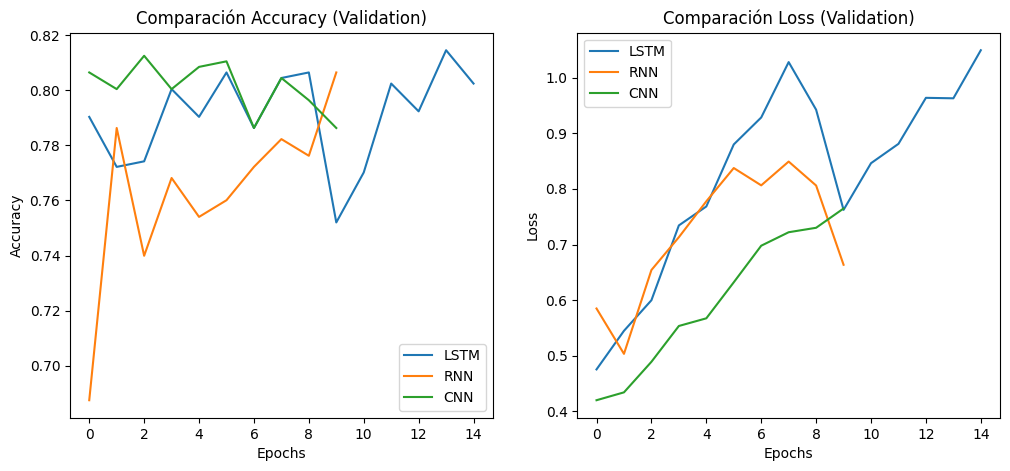

In [ ]:
import matplotlib.pyplot as plt

# Creamos una figura con tamaño más grande
plt.figure(figsize=(12,5))

# ---------------------------
# Gráfico de Accuracy
# ---------------------------
plt.subplot(1,2,1)  # 1 fila, 2 columnas, gráfico 1

# Graficamos accuracy de validación de cada modelo
plt.plot(history.history['val_accuracy'], label='LSTM')
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')

# Títulos y etiquetas
plt.title('Comparación Accuracy (Validation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Leyenda para identificar cada modelo
plt.legend()

# ---------------------------
# Gráfico de Loss
# ---------------------------
plt.subplot(1,2,2)  # gráfico 2

# Graficamos loss de validación
plt.plot(history.history['val_loss'], label='LSTM')
plt.plot(history_rnn.history['val_loss'], label='RNN')
plt.plot(history_cnn.history['val_loss'], label='CNN')

# Títulos y etiquetas
plt.title('Comparación Loss (Validation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Leyenda
plt.legend()

# Mostramos los gráficos
plt.show()

# **Pytouch y Migracion de los datos del Keras**

In [ ]:
#Importar Touch
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# Convertimos a tensores
X_train_torch = torch.tensor(X_train, dtype=torch.long)
X_test_torch = torch.tensor(X_test, dtype=torch.long)

y_train_torch = torch.tensor(y_train.values, dtype=torch.long)
y_test_torch = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
#Analisis de Sentimiento
class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SentimentModel, self).__init__()

        # Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # LSTM
        self.lstm = nn.LSTM(embed_dim, 64, batch_first=True)

        # 🔥 Capas densas (REQUERIDO)
        self.fc1 = nn.Linear(64, 64)
        self.bn1 = nn.BatchNorm1d(64)   # BatchNorm
        self.dropout = nn.Dropout(0.5)  # Dropout requerido

        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)

        self.fc_out = nn.Linear(32, 2)  # 2 clases

    def forward(self, x):
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)
        x = hidden[-1]

        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)

        x = self.fc_out(x)

        return x

In [ ]:
#Iniciar modelo
vocab_size = 5000
embed_dim = 64

model = SentimentModel(vocab_size, embed_dim)

Correccion de datos y el Loss

In [ ]:
criterion = nn.CrossEntropyLoss()  # requerido
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#Entrenamiento de datos
epochs = 15
patience = 5

best_loss = float('inf')
counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):

    # --- TRAIN ---
    model.train()

    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss = loss.item()

    # --- VALIDATION ---
    model.eval()

    with torch.no_grad():
        val_outputs = model(X_test_torch)
        val_loss = criterion(val_outputs, y_test_torch)

    val_loss_value = val_loss.item()

    train_losses.append(train_loss)
    val_losses.append(val_loss_value)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss_value:.4f}")

    # 🔥 EARLY STOPPING
    if val_loss_value < best_loss:
        best_loss = val_loss_value
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping activado")
        break

Epoch 1 | Train Loss: 0.8237 | Val Loss: 0.6754
Epoch 2 | Train Loss: 0.8016 | Val Loss: 0.6719
Epoch 3 | Train Loss: 0.7842 | Val Loss: 0.6688
Epoch 4 | Train Loss: 0.7637 | Val Loss: 0.6663
Epoch 5 | Train Loss: 0.7496 | Val Loss: 0.6647
Epoch 6 | Train Loss: 0.7333 | Val Loss: 0.6634
Epoch 7 | Train Loss: 0.7215 | Val Loss: 0.6623
Epoch 8 | Train Loss: 0.7061 | Val Loss: 0.6611
Epoch 9 | Train Loss: 0.7002 | Val Loss: 0.6597
Epoch 10 | Train Loss: 0.6855 | Val Loss: 0.6581
Epoch 11 | Train Loss: 0.6784 | Val Loss: 0.6563
Epoch 12 | Train Loss: 0.6692 | Val Loss: 0.6545
Epoch 13 | Train Loss: 0.6627 | Val Loss: 0.6524
Epoch 14 | Train Loss: 0.6511 | Val Loss: 0.6501
Epoch 15 | Train Loss: 0.6403 | Val Loss: 0.6475


##Revicion de datos y modelo

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_torch)
    preds = torch.argmax(outputs, dim=1)

accuracy = (preds == y_test_torch).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 0.7144298553466797


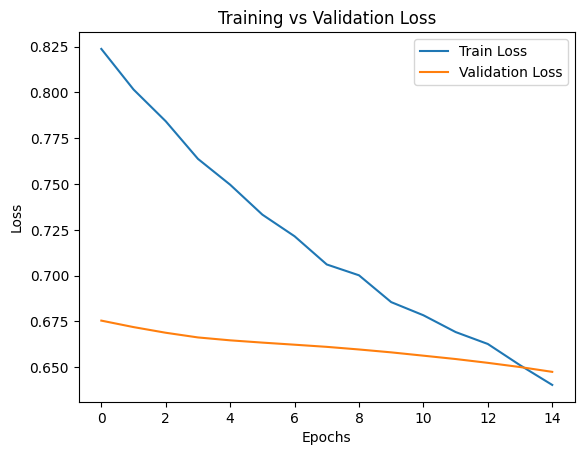

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
##quiero tener un imput para pedirle nuevas reseñas

# **Conclusión de los Hallazgos**

A partir del análisis realizado sobre el dataset de reseñas de videojuegos, se integraron técnicas de procesamiento de lenguaje natural (NLP), modelos de Machine Learning y arquitecturas de Deep Learning, permitiendo construir una visión más robusta del comportamiento de los usuarios y de los factores que influyen en la percepción de los productos.

En primer lugar, se confirma la presencia de un **desbalance en las clases**, donde aproximadamente el 69% de las reseñas corresponden a valoraciones positivas frente a un 31% de negativas. Este fenómeno sugiere que los usuarios tienden a expresar con mayor frecuencia experiencias satisfactorias, mientras que las negativas pueden traducirse en abandono o menor participación, lo que introduce un sesgo estructural en los datos.

Desde el punto de vista del modelado, los enfoques iniciales basados en LSTM implementados en Keras alcanzaron métricas muy elevadas de accuracy (cercanas al 98%), lo que en una primera instancia podría interpretarse como un alto rendimiento. Sin embargo, un análisis más profundo evidenció un claro problema de **overfitting**, donde el modelo aprendía patrones específicos del conjunto de entrenamiento sin lograr una adecuada generalización.

Para abordar esta limitación, se migró la implementación a PyTorch, incorporando una arquitectura más robusta que combina capas LSTM con capas densas, Batch Normalization y Dropout (p=0.5). Esta configuración permitió controlar el sobreajuste y mejorar la estabilidad del entrenamiento. Como resultado, el modelo alcanzó un accuracy aproximado del **71% en datos de prueba**, lo cual, si bien es inferior a los valores iniciales, representa una estimación mucho más realista de su capacidad de generalización.

El análisis del proceso de entrenamiento, reflejado en la evolución de la función de pérdida, muestra una disminución progresiva y consistente tanto en entrenamiento como en validación, sin divergencias significativas entre ambas curvas. Esto indica un aprendizaje estable y refuerza la efectividad de las técnicas de regularización aplicadas. Asimismo, la implementación de Early Stopping permitió monitorear el comportamiento del modelo y prevenir el sobreentrenamiento innecesario.

En paralelo, la incorporación de herramientas de NLP como spaCy permitió enriquecer el análisis mediante la extracción de características lingüísticas (como sustantivos, verbos, adjetivos y entidades nombradas), así como la clasificación de tipos de reseñas (opinión, queja, recomendación y humor). Este enfoque permitió complementar el análisis cuantitativo con una dimensión cualitativa, aportando mayor profundidad en la interpretación del comportamiento del usuario.

En términos de contenido, los resultados evidencian que factores como la experiencia lúdica, la interacción social y la accesibilidad para nuevos jugadores tienen un impacto significativo en la valoración de los videojuegos. Asimismo, elementos como el acceso anticipado (early access) pueden ser percibidos positivamente cuando están alineados con expectativas de participación y desarrollo activo por parte de la comunidad.

Finalmente, no se identificó una relación determinística única entre las características de un videojuego y su éxito en términos de reseñas. En cambio, los resultados sugieren que el rendimiento de un título depende de una combinación compleja de factores técnicos, sociales y perceptuales.

> **En conclusión**, este análisis demuestra que el estudio del mercado de videojuegos requiere un enfoque integral que combine **herramientas de análisis de datos con una comprensión profunda del comportamiento humano, hallazgos los cuales necesitan de la mando de un investigador y no solo de los modelos**. Si bien los modelos predictivos permiten identificar patrones relevantes, su interpretación debe contextualizarse dentro de la subjetividad del usuario y las dinámicas propias de la industria, destacando la importancia de complementar los enfoques automatizados con análisis crítico y estratégico.